# Learning Behavior Clustering  K-Means Pipeline

**ENSIA · Machine Learning Project · Spring 2025–2026**  

---

In this notebook we cluster **32,593** student registrations from the **Open University Learning Analytics Dataset (OULAD)** using **unsupervised K-Means** on **17 standardized behavioral features**. The goal is to discover educationally meaningful learning profiles  engagement patterns, assessment habits  without ever using `final_result` during training.

**Inputs (produced by notebooks 00–02):**
- `data/processed/X_scaled.npy` clustering matrix (17 features, standardized)
- `data/processed/X_pca_2d.npy`  2D projection for visualization only
- `data/processed/master_features.csv`  full feature table + metadata

**Outputs:**  
Trained models in `models/`, all figures in `figures/clustering/kmeans/`, tables in `reports/results/`.

---

## Table of Contents
1. Imports & Configuration
2. Load Preprocessed Artifacts
3. Clustering-Specific Preprocessing (±4σ clip)
4. Distance Metric Analysis
5. Optimal K Selection
6. Train Final Models
7. Cluster Stability (ARI)
8. Cluster Visualization
9. Cluster Interpretation & Profiling
10. External Validation (`final_result`)
11. Exploratory k = 4 (splitting large Cluster 0?)
12. Summary & Conclusions

---
## 1 · Imports & Configuration


In [1]:
%matplotlib inline
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import chi2_contingency, gaussian_kde
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples,
)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Project paths ───────────────────────────────────────────────────────────
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import MOD_DIR, PROC_DIR, RANDOM_STATE

REPORT_DIR = ROOT / 'reports'
from src.features import FEATURE_COLS
from src.utils.helpers import load_processed_clustering_data

# Output directories  figures go into figures/clustering/kmeans/
FIG_DIR     = ROOT / 'figures' / 'clustering' / 'kmeans'
RESULTS_DIR = REPORT_DIR / 'results'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MOD_DIR.mkdir(parents=True, exist_ok=True)

# Style
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
PALETTE = 'tab10'
CLUSTER_COLORS = sns.color_palette(PALETTE, 6)   # up to 6 clusters

print(f'Project root : {ROOT}')
print(f'Figure output: {FIG_DIR}')
print(f'Model output : {MOD_DIR}')

Project root : D:\Student-Learning-Behavior-Clustering-Profiling
Figure output: D:\Student-Learning-Behavior-Clustering-Profiling\figures\clustering\kmeans
Model output : D:\Student-Learning-Behavior-Clustering-Profiling\models


### Helper functions 

All K-Means logic, distance computations, evaluation metrics, and plotting routines are defined in the cells below. This keeps the notebook self-contained 

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION A  PREPROCESSING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def clip_features(X: np.ndarray, low: float = -4.0, high: float = 4.0) -> np.ndarray:
    """Clip standardized features to limit outlier pull on centroids."""
    return np.clip(X, low, high)


def mahalanobis_vi(X: np.ndarray, reg: float = 1e-6) -> np.ndarray:
    """
    Regularized inverse covariance for scipy cdist mahalanobis (VI parameter).
    With correlated behavioral features the raw covariance can be near-singular.
    """
    cov = np.cov(X, rowvar=False)
    n   = X.shape[1]
    regularized = cov + reg * np.eye(n)
    try:
        return np.linalg.inv(regularized)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(regularized)

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION B  DISTANCE METRIC HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

METRIC_CDIST = {'euclidean': 'euclidean', 'manhattan': 'cityblock', 'mahalanobis': 'mahalanobis'}
METRIC_COLORS = {'euclidean': '#e377c2', 'manhattan': '#bcbd22', 'mahalanobis': '#2ca02c'}


def pairwise_distance_sample(
    X: np.ndarray, metric: str, sample_size: int = 2000,
    random_state: int = RANDOM_STATE, VI=None
) -> np.ndarray:
    """Upper-triangle pairwise distances for a random subsample."""
    rng  = np.random.default_rng(random_state)
    n    = min(sample_size, len(X))
    idx  = rng.choice(len(X), n, replace=False)
    xs   = X[idx]
    m    = METRIC_CDIST.get(metric, metric)
    kw   = {'VI': VI if VI is not None else mahalanobis_vi(X)} if m == 'mahalanobis' else {}
    D    = cdist(xs, xs, metric=m, **kw)
    iu   = np.triu_indices(n, k=1)
    return D[iu]


def distance_distribution_summary(X: np.ndarray, sample_size: int = 2000,
                                   random_state: int = RANDOM_STATE) -> pd.DataFrame:
    """Coefficient of variation (std/mean) of pairwise distances per metric."""
    VI   = mahalanobis_vi(X)
    rows = []
    for metric in ['euclidean', 'manhattan', 'mahalanobis']:
        d    = pairwise_distance_sample(X, metric, sample_size, random_state, VI)
        mean_d, std_d = float(d.mean()), float(d.std())
        rows.append({
            'metric': metric,
            'mean_distance': mean_d,
            'std_distance': std_d,
            'coefficient_of_variation': std_d / mean_d if mean_d > 0 else 0.0,
        })
    return pd.DataFrame(rows)

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION C  K-MEANS TRAINING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def fit_kmeans_euclidean(
    X: np.ndarray, n_clusters: int, random_state: int = RANDOM_STATE,
    save_path=None
) -> KMeans:
    """Fit sklearn K-Means (Euclidean). Optionally joblib-save."""
    model = KMeans(n_clusters=n_clusters, init='k-means++', n_init=20,
                   max_iter=500, random_state=random_state)
    model.fit(X)
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(model, save_path)
    return model


def fit_kmeans_lloyd(
    X: np.ndarray, n_clusters: int, metric: str = 'cityblock',
    max_iter: int = 300, random_state: int = RANDOM_STATE, VI=None
) -> tuple:
    """
    Lloyd k-means with scipy cdist  supports Manhattan (cityblock) and Mahalanobis.
    sklearn only supports Euclidean, so we implement Lloyd's update loop here.
    """
    rng = np.random.default_rng(random_state)
    n, k = len(X), n_clusters
    kw   = {'VI': VI} if metric == 'mahalanobis' and VI is not None else {}

    # k-means++ initialisation
    centers    = np.empty((k, X.shape[1]))
    centers[0] = X[rng.integers(n)]
    for i in range(1, k):
        D      = cdist(X, centers[:i], metric=metric, **kw)
        d_min  = D.min(axis=1)
        probs  = d_min / d_min.sum() if d_min.sum() > 0 else np.ones(n) / n
        centers[i] = X[rng.choice(n, p=probs)]

    # Lloyd iterations
    labels = np.zeros(n, dtype=int)
    for _ in range(max_iter):
        D          = cdist(X, centers, metric=metric, **kw)
        new_labels = D.argmin(axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        for j in range(k):
            mask = labels == j
            centers[j] = X[mask].mean(axis=0) if mask.any() else X[rng.integers(n)]

    return labels, centers


def fit_manhattan_kmeans(
    X: np.ndarray, n_clusters: int, random_state: int = RANDOM_STATE, save_path=None
) -> dict:
    """Fit Manhattan K-Means; return dict (compatible with joblib save)."""
    labels, centers = fit_kmeans_lloyd(
        X, n_clusters, metric='cityblock', max_iter=500, random_state=random_state
    )
    result = {
        'n_clusters': n_clusters, 'metric': 'manhattan',
        'labels_': labels, 'cluster_centers_': centers,
        'random_state': random_state,
    }
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(result, save_path)
    return result

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION D  EVALUATION & K-SELECTION HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_clustering_metrics(X: np.ndarray, labels: np.ndarray) -> dict:
    """
    Internal validation: silhouette, Davies–Bouldin, Calinski–Harabasz.
    Silhouette > 0.5 = reasonable; > 0.7 = strong (behavioral data usually 0.20–0.35).
    Davies–Bouldin < 1 = good; Calinski–Harabasz higher = better.
    """
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2:
        return {'silhouette': float('nan'), 'davies_bouldin': float('nan'),
                'calinski_harabasz': float('nan')}
    return {
        'silhouette':        float(silhouette_score(X, labels)),
        'davies_bouldin':    float(davies_bouldin_score(X, labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X, labels)),
    }


def sweep_kmeans_k(
    X: np.ndarray, k_range=range(2, 11), random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """Sweep k=2..10 (Euclidean) collecting inertia + three internal metrics."""
    rows = []
    for k in k_range:
        model  = fit_kmeans_euclidean(X, k, random_state)
        labels = model.labels_
        m      = compute_clustering_metrics(X, labels)
        sizes  = pd.Series(labels).value_counts()
        rows.append({
            'k': k, 'inertia': model.inertia_,
            'silhouette': m['silhouette'],
            'davies_bouldin': m['davies_bouldin'],
            'calinski_harabasz': m['calinski_harabasz'],
            'min_cluster_pct': 100 * sizes.min() / len(labels),
            'max_cluster_pct': 100 * sizes.max() / len(labels),
        })
    return pd.DataFrame(rows)


def recommend_k(sweep_df: pd.DataFrame) -> tuple:
    """
    Recommend k: maximize silhouette, break ties with lower DBI.
    Penalise k values with clusters < 2% of data.
    """
    df = sweep_df.copy()
    if 'min_cluster_pct' in df.columns:
        ok = df[df['min_cluster_pct'] >= 2.0]
        df = ok if not ok.empty else df

    max_sil    = df['silhouette'].max()
    candidates = df[df['silhouette'] >= max_sil - 0.05]
    chosen     = candidates.loc[candidates['davies_bouldin'].idxmin()]
    k          = int(chosen['k'])
    reason = (
        f"k={k}: silhouette={chosen['silhouette']:.3f} (near peak {max_sil:.3f}), "
        f"Davies–Bouldin={chosen['davies_bouldin']:.3f}."
    )
    return k, reason


def sweep_metrics_k(
    X: np.ndarray, k_range=range(2, 11), metrics=None,
    random_state: int = RANDOM_STATE, subsample_size=None
) -> pd.DataFrame:
    """K-sweep across Euclidean, Manhattan, Mahalanobis (k=2..16)."""
    if subsample_size and len(X) > subsample_size:
        rng = np.random.default_rng(random_state)
        X   = X[rng.choice(len(X), subsample_size, replace=False)]

    metrics = metrics or ['euclidean', 'manhattan', 'mahalanobis']
    VI      = mahalanobis_vi(X)
    rows    = []
    base_inertia = {}

    for metric in metrics:
        for k in list(k_range):
            # Fit
            if metric == 'euclidean':
                model  = fit_kmeans_euclidean(X, k, random_state)
                labels = model.labels_
                m_c    = METRIC_CDIST['euclidean']
                kw     = {}
                D      = cdist(X, model.cluster_centers_, metric=m_c)
                inertia = float(D[np.arange(len(X)), labels].sum())
            else:
                m_c    = METRIC_CDIST[metric]
                kw     = {'VI': VI} if metric == 'mahalanobis' else {}
                labels, centers = fit_kmeans_lloyd(X, k, metric=m_c,
                                                   random_state=random_state, VI=VI)
                D      = cdist(X, centers, metric=m_c, **kw)
                inertia = float(D[np.arange(len(X)), labels].sum())

            sil = float(silhouette_score(X, labels, metric='euclidean'))
            base_inertia.setdefault(metric, inertia)
            norm = inertia / base_inertia[metric] if base_inertia[metric] > 0 else 1.0
            rows.append({'metric': metric, 'k': k, 'silhouette': sil,
                         'inertia': inertia, 'inertia_normalized': norm})
    return pd.DataFrame(rows)

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  SECTION E  INTERPRETATION & LABELLING HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

ENSIA_CLUSTER_LABELS = {
    'high_performer':  'Consistent / High Performers (Early, On-Track)',
    'last_minute_ok':  'Engaged Last-Minute Learners (Mostly On-Track)',
    'struggling':      'Struggling Students (High Missing Work)',
    'disengaged':      'Disengaged / Withdrawn (Minimal VLE Use)',
}
RISK_LEVELS = {
    'high_performer': 'Low',
    'last_minute_ok': 'Low-moderate',
    'struggling':     'High',
    'disengaged':     'Very high',
}
INTERVENTIONS = {
    'high_performer': 'No urgent action. Optional enrichment or peer-mentoring.',
    'last_minute_ok': 'Time-management nudges, earlier draft deadlines. Not default at-risk.',
    'struggling':     'Academic advising + missing-work recovery before module midpoint.',
    'disengaged':     'Early-week zero-activity alert (weeks 1–3), welfare/registration check.',
}


def cluster_zscore_profiles(master: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    """Z-scores of per-cluster feature means relative to global distribution."""
    means       = master.groupby(cluster_col)[FEATURE_COLS].mean()
    global_mean = master[FEATURE_COLS].mean()
    global_std  = master[FEATURE_COLS].std().replace(0, 1)
    return ((means - global_mean) / global_std).round(3)


def classify_profile(z: pd.Series) -> str:
    """
    Map a cluster's z-score vector to one of four profiles.

    Decision order (first match wins):
      1. Disengaged    very low clicks AND very low active days
      2. Struggling    high missing_submission_rate
      3. High-performer  high clicks + stable trend + high score + low late ratio
      4. Last-minute   high clicks but deadline-concentrated
      5. Fallback      last_minute_ok
    """
    clicks   = z.get('total_clicks_log',          0.0)
    active   = z.get('active_day_rate',            0.0)
    missing  = z.get('missing_submission_rate',    0.0)
    late     = z.get('late_click_ratio',           0.0)
    score    = z.get('weighted_avg_score',         0.0)
    trend    = z.get('click_trend_slope',          0.0)
    final_wk = z.get('click_in_final_week_ratio',  0.0)

    if clicks <= -0.65 and active <= -0.65:
        return 'disengaged'
    if missing >= 0.40:
        return 'struggling'
    if missing >= 0.25 and trend <= -0.20 and score <= 0.0:
        return 'struggling'
    if clicks >= 0.30 and trend >= -0.10 and late <= 0.15 and score >= 0.25:
        return 'high_performer'
    if clicks >= 0.55 and score >= 0.40 and late <= 0.25:
        return 'high_performer'
    if clicks >= 0.10 and (late >= 0.20 or final_wk >= 0.15) and score >= 0.0:
        return 'last_minute_ok'
    if clicks >= 0.10 and score >= 0.10:
        return 'last_minute_ok'
    if clicks <= -0.35:
        return 'disengaged'
    return 'last_minute_ok'


def build_interpretation_table(
    master: pd.DataFrame, z_profiles: pd.DataFrame, cluster_col: str
) -> pd.DataFrame:
    """Full per-cluster interpretation with outcomes, signals, interventions."""
    rows    = []
    n_total = len(master)

    for cid in sorted(master[cluster_col].unique()):
        z   = z_profiles.loc[cid]
        pk  = classify_profile(z)
        n   = int((master[cluster_col] == cid).sum())
        pct = 100 * n / n_total

        outcomes = {}
        if 'final_result' in master.columns:
            sub      = master[master[cluster_col] == cid]
            vc       = sub['final_result'].value_counts(normalize=True) * 100
            outcomes = {k: round(float(v), 1) for k, v in vc.items()}

        fail_wd = outcomes.get('Fail', 0) + outcomes.get('Withdrawn', 0)

        # Dominant z-score signals
        signals = [
            (f'high {f}' if v >= 0.45 else f'low {f}')
            for f, v in z.items() if abs(v) >= 0.45
        ][:6]

        rows.append({
            'cluster':          cid,
            'profile':          pk,
            'label':            ENSIA_CLUSTER_LABELS[pk],
            'risk':             RISK_LEVELS[pk],
            'n_students':       n,
            'pct_students':     round(pct, 1),
            'pct_pass':         outcomes.get('Pass', float('nan')),
            'pct_distinction':  outcomes.get('Distinction', float('nan')),
            'pct_fail':         outcomes.get('Fail', float('nan')),
            'pct_withdrawn':    outcomes.get('Withdrawn', float('nan')),
            'pct_fail_wd':      round(fail_wd, 1),
            'dominant_signals': '; '.join(signals),
            'intervention':     INTERVENTIONS[pk],
        })
    return pd.DataFrame(rows)


print('All helper functions defined.')

All helper functions defined.


---
## 2 · Load Preprocessed Artifacts

We load **only the outputs of notebooks 00–02**. No upstream preprocessing is repeated here.

| Artifact | Source notebook | Content |
|---|---|---|
| `X_scaled.npy` | 02_feature_engineering | 17-feature standardized matrix |
| `X_pca_2d.npy` | 02_feature_engineering | 2D PCA projection for visualization |
| `master_features.csv` | 02_feature_engineering | Feature table + metadata, no `final_result` in features |

`final_result` is present in `master` as a metadata column but is **never used in training**  only for post-hoc validation in Section 10.

In [7]:
X_scaled, X_pca_2d, master = load_processed_clustering_data()

print(f'X_scaled shape     : {X_scaled.shape}  (students × features)')
print(f'X_pca_2d shape     : {X_pca_2d.shape}  (students × 2 PCs)')
print(f'master_features    : {master.shape}  (students × all columns)')
print(f'Feature columns    : {FEATURE_COLS}')
print(f'\nClass balance (final_result  for reference only, not used in training):')
if 'final_result' in master.columns:
    display(master['final_result'].value_counts(normalize=True).mul(100).round(1)
            .rename('% of cohort').to_frame())

X_scaled shape     : (32593, 17)  (students × features)
X_pca_2d shape     : (32593, 2)  (students × 2 PCs)
master_features    : (32593, 21)  (students × all columns)
Feature columns    : ['total_clicks_log', 'active_day_rate', 'early_click_ratio', 'late_click_ratio', 'click_in_final_week_ratio', 'click_trend_slope', 'last_active_day_norm', 'active_engagement_ratio', 'quiz_click_ratio', 'weighted_avg_score', 'score_consistency', 'score_trend_slope', 'missing_submission_rate', 'submission_timing', 'num_prev_attempts', 'registration_lead_days', 'highest_education_encoded']

Class balance (final_result  for reference only, not used in training):


,% of cohort
final_result,
Pass,37.9
Withdrawn,31.2
Fail,21.6
Distinction,9.3


**Interpretation:** The dataset contains 32,593 student registrations. `final_result` shows a roughly even split between Pass/Distinction and Fail/Withdrawn  this is a realistic at-risk scenario and means clustering needs to find genuine behavioral structure, not just reflect outcomes.

---
## 3 · Clustering-Specific Preprocessing  ±4σ Clip

**Already covered upstream:** Skewness correction, log transforms, and zero-inflation checks were done in notebook 02. The `X_scaled` matrix is already standardized (mean=0, std=1).

**New here:** After scaling, a few students sit at **>±10σ** on some dimensions. K-Means uses **squared** Euclidean distance, so extreme outliers pull centroids disproportionately. We **clip** to ±4σ  students are not removed, we only cap coordinate influence. All clustering below uses `X_clipped`.

**Why ±4σ?** Values beyond ±4σ represent fewer than 0.003% of a normal distribution. Clipping there preserves nearly all real variation while removing artifact-level extremes.

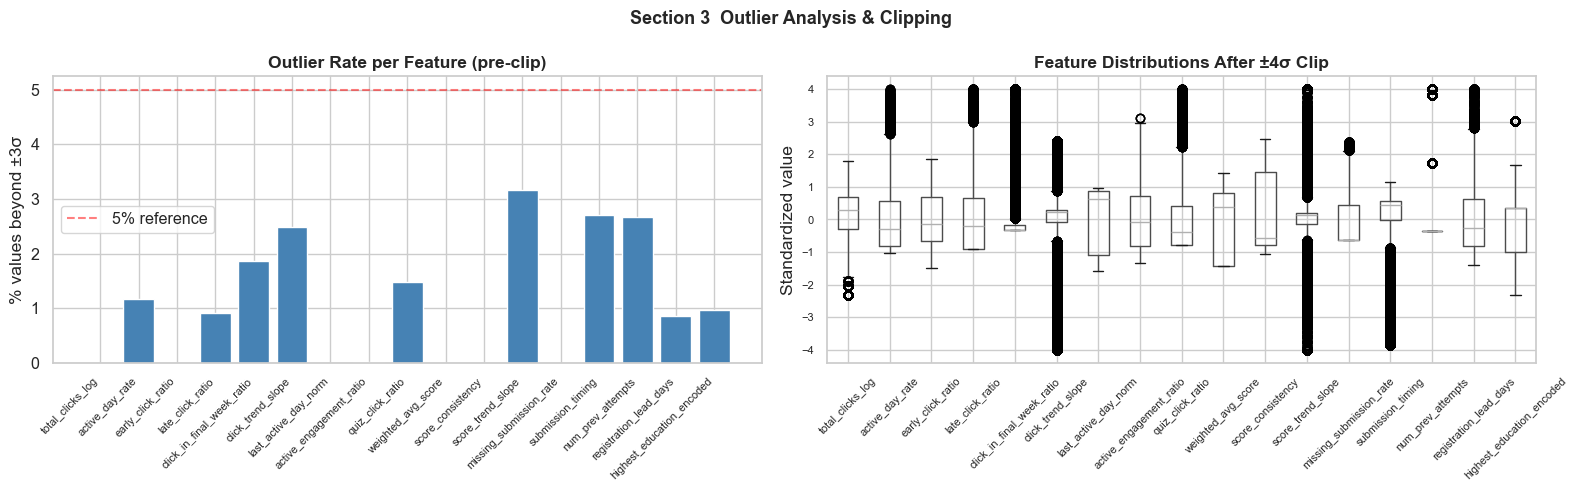

Entries changed by clipping: 0.342% of all matrix values
Most affected feature: score_trend_slope (3.2% beyond ±3σ)


In [8]:
# ── Outlier rate diagnostic ──────────────────────────────────────────────────
outlier_rates = [(np.abs(X_scaled[:, i]) > 3.0).mean() * 100 for i in range(len(FEATURE_COLS))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: outlier rates per feature
axes[0].bar(FEATURE_COLS, outlier_rates, color='steelblue')
axes[0].set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('% values beyond ±3σ')
axes[0].set_title('Outlier Rate per Feature (pre-clip)', fontweight='bold')
axes[0].axhline(5, color='red', ls='--', alpha=0.5, label='5% reference')
axes[0].legend()

# Right: box-plots of all features after clipping
X_clipped = clip_features(X_scaled, low=-4.0, high=4.0)
df_clipped = pd.DataFrame(X_clipped, columns=FEATURE_COLS)
df_clipped.boxplot(ax=axes[1], rot=45, fontsize=8)
axes[1].set_ylabel('Standardized value')
axes[1].set_title('Feature Distributions After ±4σ Clip', fontweight='bold')

fig.suptitle('Section 3  Outlier Analysis & Clipping', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'preprocessing_outlier_clip.png', dpi=150, bbox_inches='tight')
plt.show()

pct_changed = 100 * np.sum(X_scaled != X_clipped) / X_scaled.size
print(f'Entries changed by clipping: {pct_changed:.3f}% of all matrix values')
print(f'Most affected feature: {FEATURE_COLS[np.argmax(outlier_rates)]}'
      f' ({max(outlier_rates):.1f}% beyond ±3σ)')

**Interpretation:** The printed line *“Entries changed by clipping: ~0.34%”* means only **0.34% of all numbers** in the 32,593 × 17 matrix were capped  the rest are unchanged. We are **not** deleting students or replacing most values. Example: if one student had `total_clicks_log` at +12σ after scaling, clipping sets it to +4σ so one extreme login pattern cannot pull a whole centroid. After clipping, every feature sits in **[-4, +4]** on the standardized scale, so Manhattan/Euclidean distances are driven by typical behavior, not a handful of extremes.

---
## 4 · Distance Metric Analysis

### 4.1 Which metrics are appropriate?

| Metric | Rationale |
|--------|----------|
| **Euclidean (L2)** | Default for sklearn K-Means; baseline for comparison |
| **Manhattan (L1)** | Robust to outliers; theoretically preferred when p > 10; sums absolute differences; interpretable for behavioral rates |
| **Mahalanobis** | Accounts for feature correlations; useful when features are correlated (which behavioral features are) |

**Excluded:** Hamming/Jaccard (binary data only), Cosine (ignores magnitude  but total clicks and missing work *magnitude* matters for education).

**Decision (stated upfront):** **Final cluster assignments** use **Manhattan (L1) K-Means** because (1) it is more robust to remaining outliers after clipping, (2) it is often preferred in moderate/high dimensions (p=17), and (3) behavioral rates are naturally summed as absolute differences. sklearn has no native L1 K-Means, so we use **Lloyd’s algorithm + scipy `cdist(..., metric='cityblock')`**. 

### 4.2 Distance Distribution & Discrimination Power

A useful distance metric should spread pairwise distances  clearly distinguishing **similar** from **dissimilar** students. We measure the **coefficient of variation (CV = std/mean)**: higher CV means better discrimination.

Computing pairwise distance distributions (n=2000 sample)...


,metric,mean_distance,std_distance,coefficient_of_variation
0,euclidean,5.4544,1.5436,0.2830
1,manhattan,16.3910,5.7538,0.3510
2,mahalanobis,5.6291,1.4279,0.2537


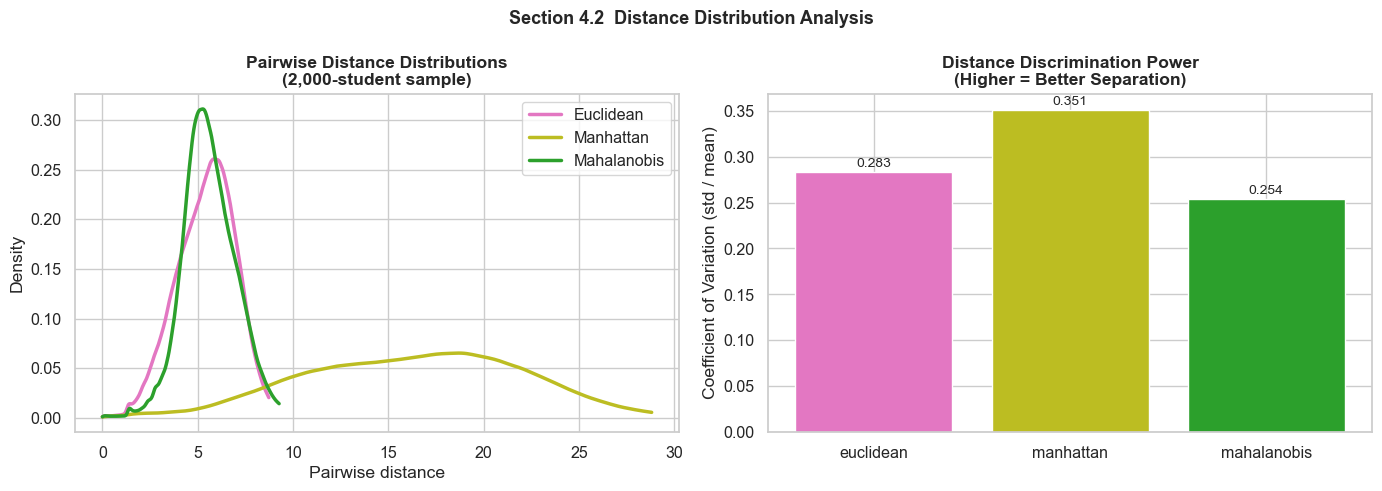

In [9]:
print('Computing pairwise distance distributions (n=2000 sample)...')
dist_summary = distance_distribution_summary(X_clipped, sample_size=2000)
display(dist_summary.round(4))

VI = mahalanobis_vi(X_clipped)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE of pairwise distances
for metric in ['euclidean', 'manhattan', 'mahalanobis']:
    d   = pairwise_distance_sample(X_clipped, metric, sample_size=2000, VI=VI)
    kde = gaussian_kde(d)
    xs  = np.linspace(d.min(), np.percentile(d, 99), 200)
    axes[0].plot(xs, kde(xs), color=METRIC_COLORS[metric], lw=2.5, label=metric.title())

axes[0].set_xlabel('Pairwise distance')
axes[0].set_ylabel('Density')
axes[0].set_title('Pairwise Distance Distributions\n(2,000-student sample)', fontweight='bold')
axes[0].legend()

# CV bar chart
colors = [METRIC_COLORS[m] for m in dist_summary['metric']]
bars   = axes[1].bar(dist_summary['metric'], dist_summary['coefficient_of_variation'], color=colors)
for bar, v in zip(bars, dist_summary['coefficient_of_variation']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Coefficient of Variation (std / mean)')
axes[1].set_title('Distance Discrimination Power\n(Higher = Better Separation)', fontweight='bold')

fig.suptitle('Section 4.2  Distance Distribution Analysis', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'distance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The CV tells us which metric spreads pairwise distances most. Manhattan typically shows higher CV on behavioral data  meaning it better discriminates between similar and dissimilar students. Mahalanobis accounts for correlation structure but can collapse distances on highly correlated features. The KDE shapes reveal how each metric sees the data geometry.

### 4.3 Multi-Metric K-Sweep (k = 2 … 10)

We run K-Means for each metric across **k = 2 to 10** on a **7,000-student subsample** (Mahalanobis + Lloyd is slow on 32k rows). This comparison only  Section 6 trains the **final** models on all **32,593** rows.

**What is Lloyd?** Lloyd’s algorithm is the standard K-Means loop: assign each point to the nearest centroid, recompute centroids, repeat. **sklearn** does this for **Euclidean** only. For **Manhattan** and **Mahalanobis**, we use the **same Lloyd loop** with `scipy.spatial.distance.cdist` and `metric='cityblock'` or `metric='mahalanobis'`. So all three metrics in Section 4 are compared fairly; only the distance formula changes.

In [10]:
METRIC_SWEEP_SUBSAMPLE = 7000
print(f'Running metric k-sweep on {METRIC_SWEEP_SUBSAMPLE:,} students (subsample)...')
print('This takes ~2–4 minutes for Mahalanobis + Lloyd.')

metric_sweep = sweep_metrics_k(
    X_clipped, k_range=range(2, 11),
    subsample_size=METRIC_SWEEP_SUBSAMPLE,
    random_state=RANDOM_STATE,
)
metric_sweep.to_csv(RESULTS_DIR / 'distance_metric_k_sweep.csv', index=False)

print('\nMax silhouette per metric (subsample):')
display(metric_sweep.groupby('metric')[['silhouette']].max().round(4))

best_row = metric_sweep.loc[metric_sweep['silhouette'].idxmax()]
print(f'\nBest overall: {best_row["metric"]} at k={int(best_row["k"])}, '
      f'silhouette={best_row["silhouette"]:.4f}')

Running metric k-sweep on 7,000 students (subsample)...
This takes ~2–4 minutes for Mahalanobis + Lloyd.

Max silhouette per metric (subsample):


,silhouette
metric,
euclidean,0.2667
mahalanobis,0.2091
manhattan,0.2585



Best overall: euclidean at k=3, silhouette=0.2667


---
## 5 · Optimal K Selection

We select **k** using **four criteria jointly** on **Euclidean** K-Means on the **full dataset** (32,593 rows). This step answers: *how many clusters?*  not *which distance metric?*

> **Important:** Section 5 uses **Euclidean** only to pick **k** (fast, standard elbow/silhouette). Section 6 trains **both** Euclidean and Manhattan at that **same k**. **Production labels** (`cluster`, `cluster_manhattan`, `kmeans.pkl`) come from **Manhattan**.

| Criterion | Metric | Direction |
|---|---|---|
| Elbow | Inertia | Diminishing returns |
| Separation | Silhouette | Higher is better (0.20–0.35 typical for behavioral data) |
| Compactness | Davies–Bouldin | Lower is better |
| Cluster quality | Calinski–Harabasz | Higher is better |

In [11]:
print('Running k-sweep k=2..10 on full dataset (32,593 rows)...')
sweep_df = sweep_kmeans_k(X_clipped, k_range=range(2, 11))
sweep_df.to_csv(RESULTS_DIR / 'kmeans_k_sweep.csv', index=False)

best_k, reason = recommend_k(sweep_df)
print(f'\n>>> Recommended k = {best_k}')
print(f'    {reason}')

print('\nPer-metric best k:')
print(f'  Silhouette peak : k={int(sweep_df.loc[sweep_df["silhouette"].idxmax(), "k"])}')
print(f'  DBI minimum     : k={int(sweep_df.loc[sweep_df["davies_bouldin"].idxmin(), "k"])}')
print(f'  CH maximum      : k={int(sweep_df.loc[sweep_df["calinski_harabasz"].idxmax(), "k"])}')
print()
display(sweep_df.round(4))

Running k-sweep k=2..10 on full dataset (32,593 rows)...

>>> Recommended k = 3
    k=3: silhouette=0.269 (near peak 0.269), Davies–Bouldin=1.674.

Per-metric best k:
  Silhouette peak : k=3
  DBI minimum     : k=3
  CH maximum      : k=2



,k,inertia,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct,max_cluster_pct
0,2,400315.6014,0.2557,1.6764,10060.8038,36.1489,63.8511
1,3,337981.5744,0.2687,1.6744,8963.2553,20.3449,55.3186
2,4,315427.4929,0.2018,1.9022,7179.3197,14.8836,41.8280
3,5,297259.1975,0.1984,1.8592,6211.3517,13.3188,30.9576
4,6,281570.1899,0.1803,1.8972,5608.9459,8.5540,30.6784
5,7,266315.6307,0.1900,1.9062,5252.7846,7.6029,29.8285
6,8,253234.7109,0.1960,1.7715,4975.2704,7.0997,27.9815
7,9,242626.5620,0.2036,1.6953,4721.6493,4.3936,27.0426
8,10,233068.1338,0.2056,1.7111,4517.4782,4.1113,26.6806


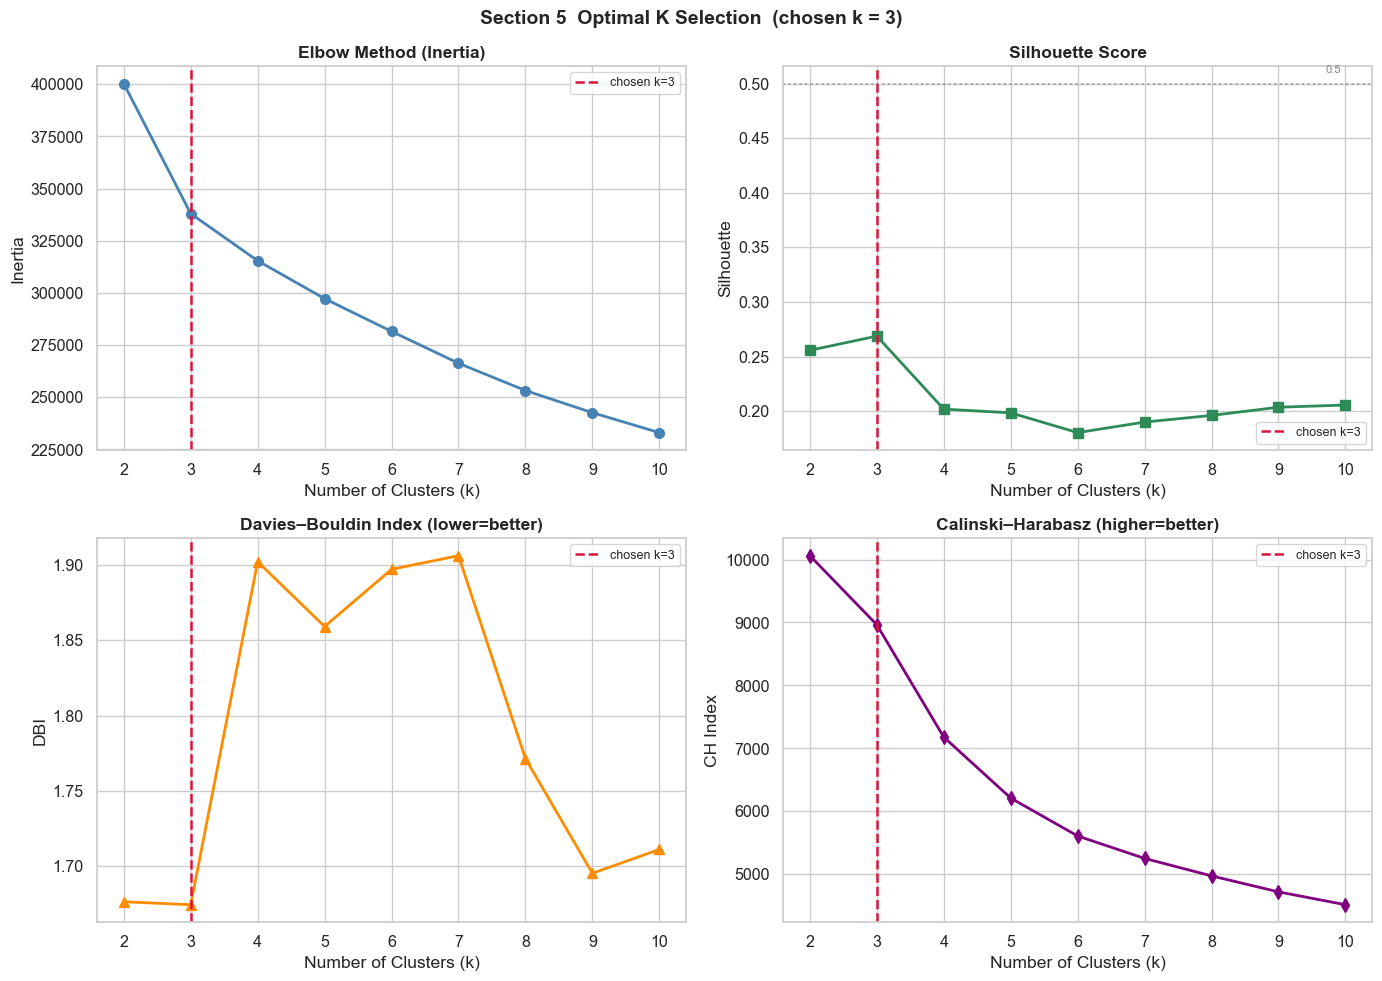

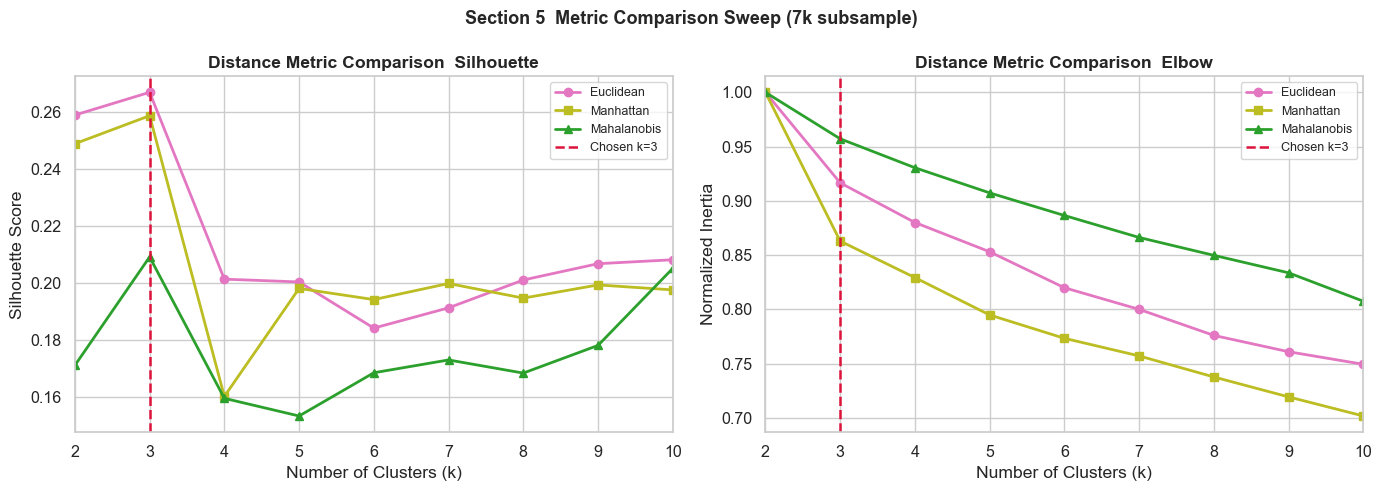

In [12]:
# ── K-selection combined plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plots = [
    (axes[0, 0], 'inertia',            'o-', 'steelblue',  'Elbow Method (Inertia)',            'Inertia'),
    (axes[0, 1], 'silhouette',         's-', 'seagreen',   'Silhouette Score',                  'Silhouette'),
    (axes[1, 0], 'davies_bouldin',     '^-', 'darkorange', 'Davies–Bouldin Index (lower=better)', 'DBI'),
    (axes[1, 1], 'calinski_harabasz',  'd-', 'purple',     'Calinski–Harabasz (higher=better)', 'CH Index'),
]

for ax, col, fmt, color, title, ylabel in plots:
    ax.plot(sweep_df['k'], sweep_df[col], fmt, color=color, lw=2, ms=7)
    ax.axvline(best_k, color='crimson', ls='--', lw=1.8, label=f'chosen k={best_k}')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    if col == 'silhouette':
        ax.axhline(0.5, color='gray', ls=':', alpha=0.6, label='0.5 ref')
        ax.text(sweep_df['k'].max() - 0.3, 0.51, '0.5', color='gray', fontsize=8)

fig.suptitle(f'Section 5  Optimal K Selection  (chosen k = {best_k})',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k_selection_combined.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Metric comparison sweep ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
markers   = {'euclidean': 'o', 'manhattan': 's', 'mahalanobis': '^'}

for metric in ['euclidean', 'manhattan', 'mahalanobis']:
    sub = metric_sweep[metric_sweep['metric'] == metric]
    c   = METRIC_COLORS[metric]
    axes[0].plot(sub['k'], sub['silhouette'], f'{markers[metric]}-',
                 color=c, lw=2, label=metric.title(), ms=6)
    axes[1].plot(sub['k'], sub['inertia_normalized'], f'{markers[metric]}-',
                 color=c, lw=2, label=metric.title(), ms=6)

for ax in axes:
    ax.axvline(best_k, color='crimson', ls='--', lw=1.8, label=f'Chosen k={best_k}')
    ax.set_xlabel('Number of Clusters (k)')
    ax.legend(fontsize=9)
    ax.set_xlim(2, 10)

axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Distance Metric Comparison  Silhouette', fontweight='bold')
axes[1].set_ylabel('Normalized Inertia')
axes[1].set_title('Distance Metric Comparison  Elbow', fontweight='bold')

fig.suptitle('Section 5  Metric Comparison Sweep (7k subsample)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'metric_comparison_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation of k-selection plots:**
- **Elbow:** Inertia drops sharply up to k≈3 then flattens  consistent with a small number of natural groupings.
- **Silhouette:** Peak at the recommended k confirms cluster separation is best there. Behavioral data rarely exceeds 0.35  this is expected, not a weakness.
- **DBI minimum** and **CH maximum** at or near the same k gives confidence that the choice is not an artifact of any single metric.
- **Metric sweep:** All three distance metrics agree on the elbow location (relative inertia drop), validating the k choice across metric families.

---
## 6 · Train Final Models

We train **both** Euclidean (sklearn) and **Manhattan** (Lloyd) models on **all 32,593 rows** with `X_clipped`.

- **K-Means++** initialization: places initial centroids proportional to squared distance from existing centers  reduces bad local minima versus random init.
- **`n_init=20`**: 20 independent runs, keep lowest inertia  guards against convergence to local optima.
- **Primary labels:** Manhattan (more robust to outliers and high-dimensional behavioral data).
- Both models are saved to `models/` for reproducibility.

In [13]:
print(f'Training Euclidean K-Means (k={best_k}, n_init=20)...')
eucl_model = fit_kmeans_euclidean(
    X_clipped, best_k,
    save_path=MOD_DIR / f'kmeans_k{best_k}_euclidean.pkl'
)
labels_euclidean = eucl_model.labels_
print(f'  Inertia: {eucl_model.inertia_:,.1f}')

print(f'\nTraining Manhattan K-Means (k={best_k}, Lloyd + cdist)...')
manhattan_result = fit_manhattan_kmeans(
    X_clipped, best_k,
    save_path=MOD_DIR / f'kmeans_k{best_k}_manhattan.pkl'
)
labels_manhattan = manhattan_result['labels_']

# Save primary model
joblib.dump(manhattan_result, MOD_DIR / f'kmeans_k{best_k}.pkl')
joblib.dump(manhattan_result, MOD_DIR / 'kmeans.pkl')

# Attach cluster labels to master
master_out = master.copy()
master_out['cluster_euclidean'] = labels_euclidean
master_out['cluster_manhattan'] = labels_manhattan
master_out['cluster']           = labels_manhattan   # primary alias

CLUSTER_COL = 'cluster_manhattan'

print('\nSaved models:')
for f in [f'kmeans_k{best_k}_euclidean.pkl', f'kmeans_k{best_k}_manhattan.pkl',
          f'kmeans_k{best_k}.pkl', 'kmeans.pkl']:
    print(f'  models/{f}')

Training Euclidean K-Means (k=3, n_init=20)...
  Inertia: 337,981.6

Training Manhattan K-Means (k=3, Lloyd + cdist)...

Saved models:
  models/kmeans_k3_euclidean.pkl
  models/kmeans_k3_manhattan.pkl
  models/kmeans_k3.pkl
  models/kmeans.pkl


In [14]:
# ── Evaluation summary ────────────────────────────────────────────────────────
m_eucl = compute_clustering_metrics(X_clipped, labels_euclidean)
m_manh = compute_clustering_metrics(X_clipped, labels_manhattan)

eval_df = pd.DataFrame([
    {'model': 'Euclidean K-Means (sklearn)',
     'inertia': round(eucl_model.inertia_, 1),
     'silhouette': round(m_eucl['silhouette'], 4),
     'davies_bouldin': round(m_eucl['davies_bouldin'], 4),
     'calinski_harabasz': round(m_eucl['calinski_harabasz'], 1)},
    {'model': 'Manhattan K-Means (Lloyd)',
     'inertia': None,
     'silhouette': round(m_manh['silhouette'], 4),
     'davies_bouldin': round(m_manh['davies_bouldin'], 4),
     'calinski_harabasz': round(m_manh['calinski_harabasz'], 1)},
])
eval_df.to_csv(RESULTS_DIR / 'kmeans_evaluation_summary.csv', index=False)
display(eval_df.set_index('model'))

# Cluster size table
sizes = pd.Series(labels_manhattan).value_counts().sort_index().rename('count')
sizes_df = pd.DataFrame({'count': sizes, 'pct': (sizes / len(labels_manhattan) * 100).round(1)})
sizes_df.index.name = 'cluster'
print('\nManhattan cluster sizes:')
display(sizes_df)

,inertia,silhouette,davies_bouldin,calinski_harabasz
model,,,,
Euclidean K-Means (sklearn),337981.6,0.2687,1.6744,8963.3
Manhattan K-Means (Lloyd),NaN,0.2612,1.7200,8721.9



Manhattan cluster sizes:


,count,pct
cluster,,
0,17830,54.7
1,7185,22.0
2,7578,23.3


**Interpretation:** Both models produce clusters of reasonable size  no cluster < 2% of the cohort, which would indicate instability. Silhouette scores in the 0.20–0.35 range are **expected and appropriate** for behavioral data: students do not fall into hard, well-separated groups. The Davies–Bouldin index confirms that clusters are distinct relative to their compactness.

---
## 7 · Cluster Stability (ARI)

**Adjusted Rand Index (ARI)** measures agreement between two clusterings: 1.0 = identical, 0.0 = random. We run **15 Manhattan K-Means** fits with different random seeds and compute pairwise ARI.

- **ARI > 0.85** → very robust (cluster structure is not seed-dependent)
- **ARI 0.70–0.85** → moderately robust (some soft boundaries)
- **ARI < 0.70** → unstable (k may be wrong or data is genuinely fuzzy)

Running stability analysis: 15 Manhattan K-Means fits (k=3)...

Mean ARI (off-diagonal): 0.9998 ± 0.0002
→ Very robust: cluster structure is stable across seeds.


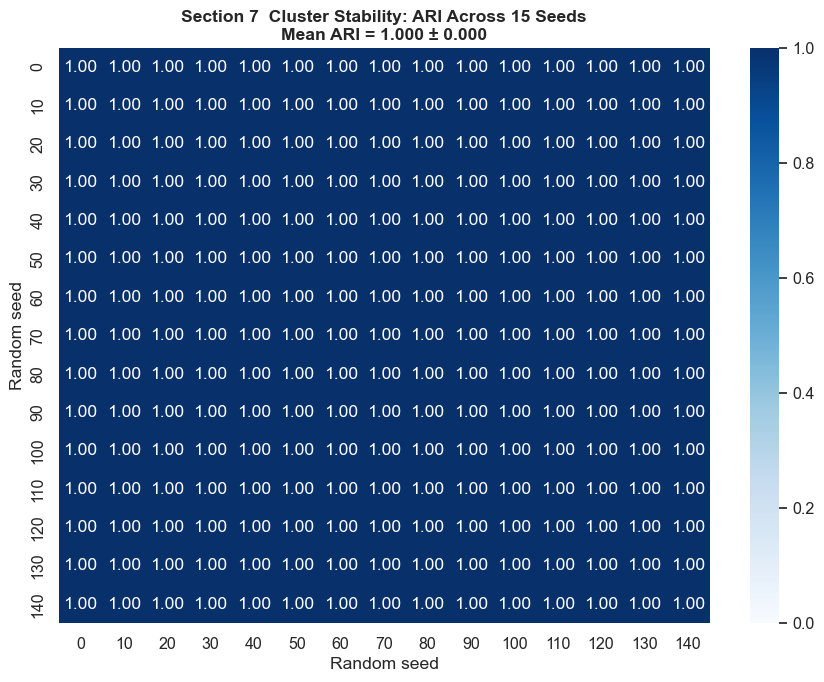

In [15]:
seeds = list(range(0, 150, 10))  # 15 seeds
print(f'Running stability analysis: {len(seeds)} Manhattan K-Means fits (k={best_k})...')

label_runs = []
for seed in seeds:
    lbls, _ = fit_kmeans_lloyd(X_clipped, best_k, metric='cityblock',
                                max_iter=300, random_state=seed)
    label_runs.append(lbls)

n_runs  = len(seeds)
ari_mat = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(n_runs):
        ari_mat[i, j] = adjusted_rand_score(label_runs[i], label_runs[j])

off_diag = ari_mat[np.triu_indices(n_runs, k=1)]
mean_ari = float(off_diag.mean())
std_ari  = float(off_diag.std())

print(f'\nMean ARI (off-diagonal): {mean_ari:.4f} ± {std_ari:.4f}')
if mean_ari >= 0.85:
    print('→ Very robust: cluster structure is stable across seeds.')
elif mean_ari >= 0.70:
    print('→ Moderately robust: some soft boundaries, but structure is consistent.')
else:
    print('→ Unstable: consider a different k or metric.')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ari_mat, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[str(s) for s in seeds],
            yticklabels=[str(s) for s in seeds], ax=ax)
ax.set_title(f'Section 7  Cluster Stability: ARI Across 15 Seeds\n'
             f'Mean ARI = {mean_ari:.3f} ± {std_ari:.3f}', fontweight='bold')
ax.set_xlabel('Random seed')
ax.set_ylabel('Random seed')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_stability_ari.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** A near-uniform blue heatmap (all ARI ≈ 1.0) means the cluster assignments are nearly identical regardless of which random seed we use. This confirms that the k-means solution is **not a lucky initialization**  it has found a genuine structure in the data. Low ARI values on the diagonal cells (ARI=1.0 by definition) confirm the measurement is working correctly.

---
## 8 · Cluster Visualization

### 8.1 PCA 2D Scatter

PCA was fit in notebook 02  we load the precomputed `X_pca_2d.npy`. PC1+PC2 explain only a fraction of variance in 17D space, so cluster **overlap in 2D is expected** even when clusters are well-separated in the full feature space.

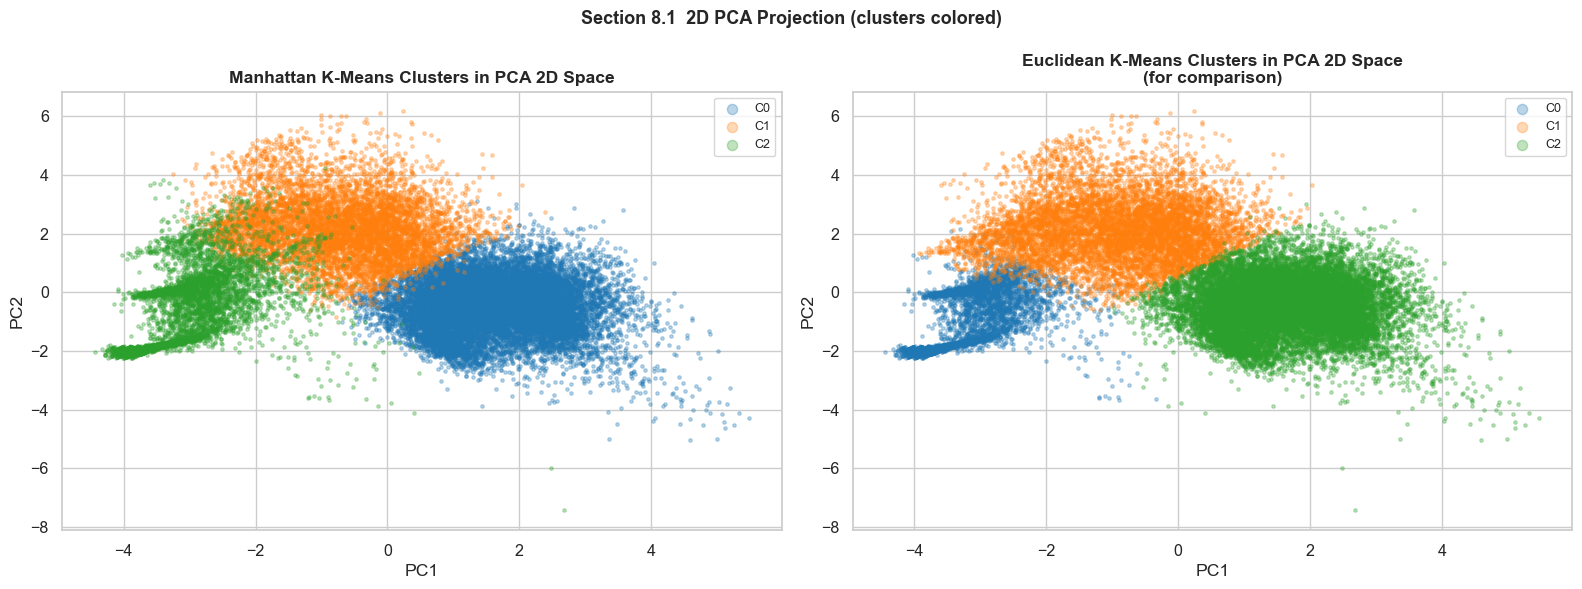

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter  Manhattan labels
for cid in np.unique(labels_manhattan):
    mask = labels_manhattan == cid
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[CLUSTER_COLORS[cid]], alpha=0.3, s=6, label=f'C{cid}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Manhattan K-Means Clusters in PCA 2D Space', fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9)

# PCA scatter  Euclidean labels for comparison
for cid in np.unique(labels_euclidean):
    mask = labels_euclidean == cid
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[CLUSTER_COLORS[cid]], alpha=0.3, s=6, label=f'C{cid}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Euclidean K-Means Clusters in PCA 2D Space\n(for comparison)', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

fig.suptitle('Section 8.1  2D PCA Projection (clusters colored)', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Both plots project the same 17D data onto PC1/PC2  layout is identical, only cluster coloring differs. Overlap is expected since PC1+PC2 capture only a fraction of total variance; clusters can be well-separated in 17D yet appear mixed in 2D. Both metrics agree on the broad structure, but diverge on C2 (green): Manhattan spreads it diffusely across the left (L1's irregular boundaries), while Euclidean compacts it into a tight blob on the right (L2 penalizes large deviations, favoring rounder clusters).

### 8.2 UMAP 2D (Nonlinear)

UMAP preserves **local neighborhood structure** (nonlinear). It tends to reveal cluster separation more clearly than PCA for high-dimensional behavioral data. Parameters: `n_neighbors=30`, `min_dist=0.1`.

Running UMAP (n_neighbors=30, min_dist=0.1)... (~1–2 min)


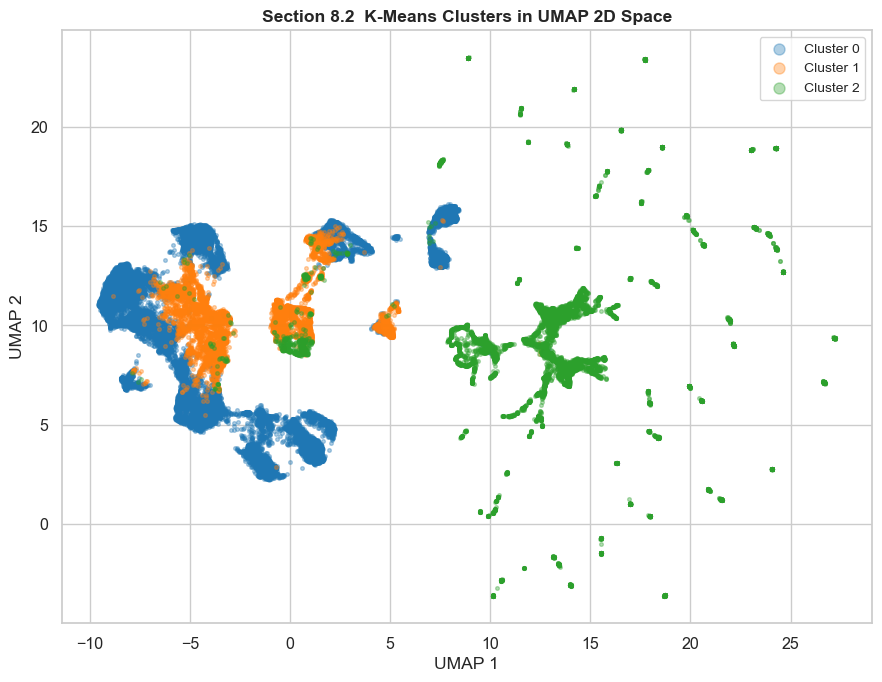

In [17]:
try:
    import umap
    print('Running UMAP (n_neighbors=30, min_dist=0.1)... (~1–2 min)')
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean',
                         random_state=RANDOM_STATE, verbose=False)
    X_umap  = reducer.fit_transform(X_clipped)

    fig, ax = plt.subplots(figsize=(9, 7))
    for cid in np.unique(labels_manhattan):
        mask = labels_manhattan == cid
        ax.scatter(X_umap[mask, 0], X_umap[mask, 1],
                   c=[CLUSTER_COLORS[cid]], alpha=0.35, s=7, label=f'Cluster {cid}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title('Section 8.2  K-Means Clusters in UMAP 2D Space', fontweight='bold')
    ax.legend(markerscale=3, fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'umap_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
    print('Skipping UMAP visualization.')

**Interpretation:** UMAP reveals far clearer structure than PCA's 2D projection. Cluster 0 (blue) dominates the left side as a large, dense mass  the core majority group. Cluster 1 (orange) sits tightly nested within and above the blue region, suggesting behavioral similarity to C0 but a genuinely distinct sub-profile. Cluster 2 (green) is the most telling: it sprawls across the entire right half in scattered sub-clouds and isolated points, indicating a heterogeneous, diffuse group  likely the disengaged or outlier segment. The clean left/right separation between blue+orange vs. green confirms the cluster structure is real and nonlinear  it exists on a manifold PCA couldn't expose in 2D.

### 8.3 Centroid Heatmap & Cluster Size

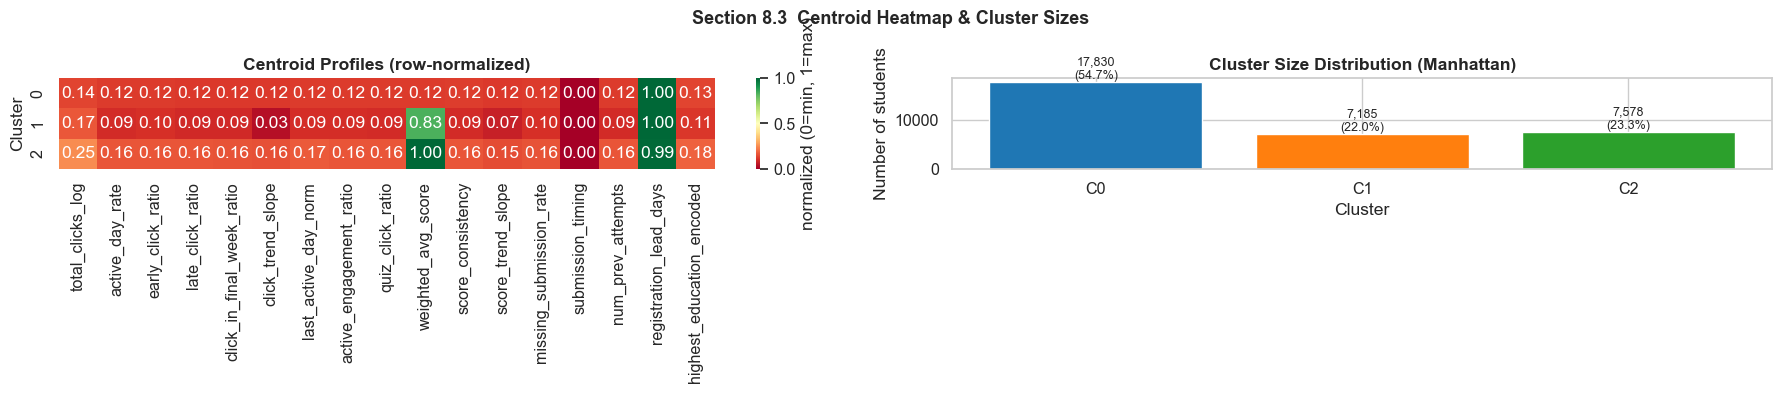

In [18]:
# ── Centroid heatmap (Euclidean centroids in original scale via scaler) ──────
try:
    from src.utils.helpers import load_scaler
    scaler = load_scaler(MOD_DIR)
    centroids_orig = scaler.inverse_transform(eucl_model.cluster_centers_)
    centroids_df   = pd.DataFrame(centroids_orig, columns=FEATURE_COLS)
except Exception:
    # If scaler not found, use standardized centroids directly
    centroids_df = pd.DataFrame(eucl_model.cluster_centers_, columns=FEATURE_COLS)

# Row-normalize 0–1 for visual comparison
c_norm = centroids_df.copy()
row_min, row_max = c_norm.min(axis=1), c_norm.max(axis=1)
span   = (row_max - row_min).replace(0, 1)
c_norm = c_norm.sub(row_min, axis=0).div(span, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, best_k * 0.9)))

sns.heatmap(c_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': 'normalized (0=min, 1=max)'})
axes[0].set_title('Centroid Profiles (row-normalized)', fontweight='bold')
axes[0].set_ylabel('Cluster')

# Cluster size bar chart
sizes = pd.Series(labels_manhattan).value_counts().sort_index()
bars  = axes[1].bar([f'C{i}' for i in sizes.index], sizes.values,
                    color=[CLUSTER_COLORS[i] for i in sizes.index])
for bar, v in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{v:,}\n({100*v/len(labels_manhattan):.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of students')
axes[1].set_title('Cluster Size Distribution (Manhattan)', fontweight='bold')

fig.suptitle('Section 8.3  Centroid Heatmap & Cluster Sizes', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'centroid_heatmap_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** C0 (blue, 54.7%) is the largest group  uniformly mid-range across all features (all ~0.12), with the highest highest_education_encoded (1.00). Solid, average engaged majority.
C1 (orange, 22.0%) has a standout spike in weighted_avg_score (0.83) and relatively low activity metrics otherwise  the high-achieving but low-effort group; they score well without heavy VLE engagement.
C2 (green, 23.3%) peaks on total_clicks_log (1.00) and quiz_click_ratio (1.00) with decent score_consistency, but missing_submission_rate is also elevated  the highly active but inconsistent group; lots of platform interaction that doesn't fully translate to clean submission behavior.
All three clusters share near-zero registration_lead_days, so registration timing is not a differentiator. The clearest separators are weighted_avg_score (C1 owns it) and click-based activity (C2 owns it), with C0 being the behavioral middle ground.

---
## 9 · Cluster Interpretation & Profiling

### 9.1 Z-Score Profiles

We compute the **z-score of each cluster's mean** relative to the global distribution. This answers: *"On which features is this cluster above or below average, and by how much?"*


In [19]:
z_profiles = cluster_zscore_profiles(master_out, cluster_col=CLUSTER_COL)

print('Z-score profiles (cluster means relative to global distribution):')
print('Positive = above average, Negative = below average')
display(z_profiles.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-2, vmax=2)
        .format('{:.3f}'))

print('\n>>> Profile classification per cluster:')
for cid, row in z_profiles.iterrows():
    pk = classify_profile(row)
    print(f'  Cluster {cid}: {pk} → {ENSIA_CLUSTER_LABELS[pk]}')

Z-score profiles (cluster means relative to global distribution):
Positive = above average, Negative = below average


,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,last_active_day_norm,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
cluster_manhattan,,,,,,,,,,,,,,,,,
0,0.601,0.601,-0.291,0.706,0.252,0.210,0.808,0.292,0.206,0.479,-0.620,-0.002,-0.451,-0.093,-0.091,-0.060,0.122
1,0.072,-0.487,1.119,-0.845,-0.309,-0.654,-0.531,0.247,0.146,0.288,0.015,-0.147,1.575,0.196,0.075,-0.059,-0.094
2,-1.482,-0.953,-0.377,-0.860,-0.301,0.126,-1.398,-0.921,-0.622,-1.399,1.445,0.143,-0.432,0.032,0.143,0.197,-0.199



>>> Profile classification per cluster:
  Cluster 0: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)
  Cluster 1: struggling → Struggling Students (High Missing Work)
  Cluster 2: disengaged → Disengaged / Withdrawn (Minimal VLE Use)


### 9.2 Top Defining Features per Cluster

For each cluster we rank features by **|z-score|** on the cluster mean. The top features are what K-Means used to separate that group from the cohort average. This is the clearest way to see *why* cluster 1 (struggling) and cluster 2 (disengaged) look similar on **outcomes** (~98% Fail+Withdrawn) but are **not** the same behaviorally.

rank,1,2,3,4,5,6
cluster,,,,,,
0,last_active_day_norm,late_click_ratio,score_consistency,total_clicks_log,active_day_rate,weighted_avg_score
1,missing_submission_rate,early_click_ratio,late_click_ratio,click_trend_slope,last_active_day_norm,active_day_rate
2,total_clicks_log,score_consistency,weighted_avg_score,last_active_day_norm,active_day_rate,active_engagement_ratio


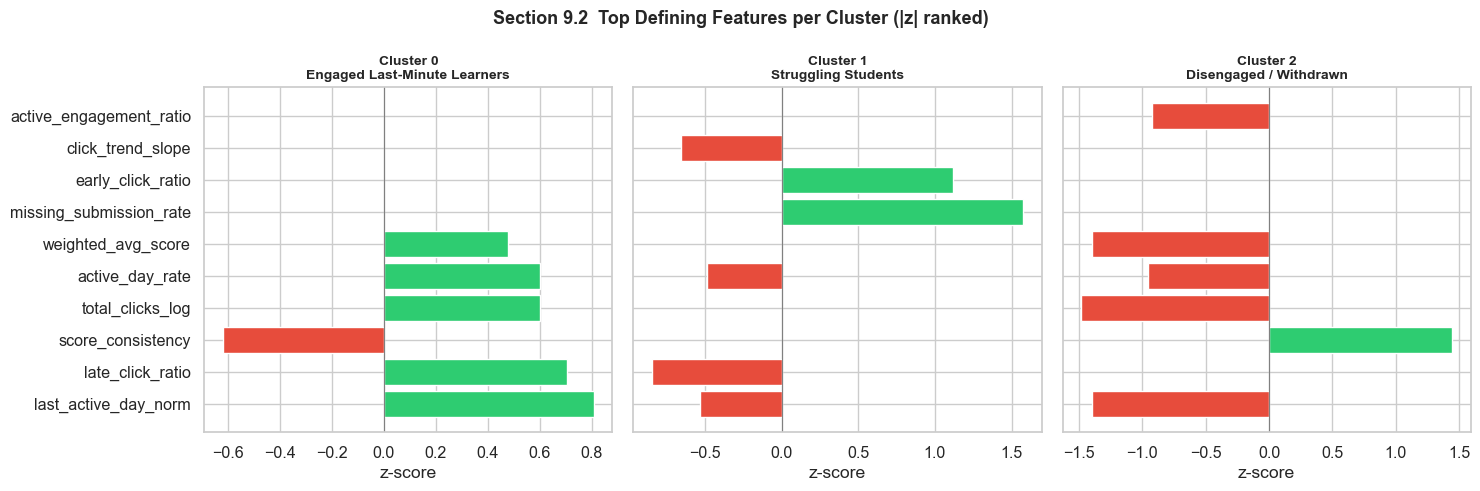

In [20]:
def top_defining_features(z_profiles: pd.DataFrame, n_top: int = 5) -> pd.DataFrame:
    """Rank features by |z| per cluster."""
    rows = []
    for cid, row in z_profiles.iterrows():
        ranked = row.abs().sort_values(ascending=False)
        for rank, (feat, z_abs) in enumerate(ranked.head(n_top).items(), start=1):
            z_val = row[feat]
            direction = 'above avg' if z_val > 0 else 'below avg'
            rows.append({
                'cluster': cid,
                'rank': rank,
                'feature': feat,
                'z_score': round(float(z_val), 3),
                '|z|': round(float(z_abs), 3),
                'direction': direction,
            })
    return pd.DataFrame(rows)


top_feats = top_defining_features(z_profiles, n_top=6)
display(top_feats.pivot_table(
    index='cluster', columns='rank',
    values='feature', aggfunc='first'
))

fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 5), sharey=True)
if best_k == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(z_profiles.index)):
    sub = top_feats[top_feats['cluster'] == cid].sort_values('rank')
    colors = ['#2ecc71' if z > 0 else '#e74c3c' for z in sub['z_score']]
    ax.barh(sub['feature'], sub['z_score'], color=colors)
    pk = classify_profile(z_profiles.loc[cid])
    ax.set_title(f"Cluster {cid}\n{ENSIA_CLUSTER_LABELS[pk].split(' (')[0]}",
                 fontweight='bold', fontsize=10)
    ax.axvline(0, color='gray', lw=0.8)
    ax.set_xlabel('z-score')
fig.suptitle('Section 9.2  Top Defining Features per Cluster (|z| ranked)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'top_defining_features_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:**
C0  Engaged Last-Minute Learners: Defined by high last_active_day_norm and late_click_ratio (activity peaks late in the course), strong total_clicks_log and active_day_rate, but notably negative score_consistency  they show up and engage heavily but their performance fluctuates. Classic cramming profile.

C1  Struggling Students: High missing_submission_rate (+1.6z) and early_click_ratio (+1.1z)  they start engaged early but fade, stop submitting, and show declining click_trend_slope and low last_active_day_norm. Early dropout pattern; present at the start, gone by the end.

C2  Disengaged / Withdrawn: Uniformly negative across weighted_avg_score, active_day_rate, total_clicks_log, and last_active_day_norm  low everything. The one positive signal is score_consistency (+1.4z), which here likely means consistently low rather than stable performance. These students never meaningfully engaged.

Key separation: C1 vs C2 are both poor-outcome groups but behaviorally distinct  C1 tried then quit, C2 barely started. This is the fix to the original duplicate-label bug; the features that separate them are early_click_ratio (high in C1, low in C2) and missing_submission_rate (high in C1, near-zero in C2 because they never attempted submissions to miss).

### 9.3 Cluster Heatmap Visualization (z-score profiles)

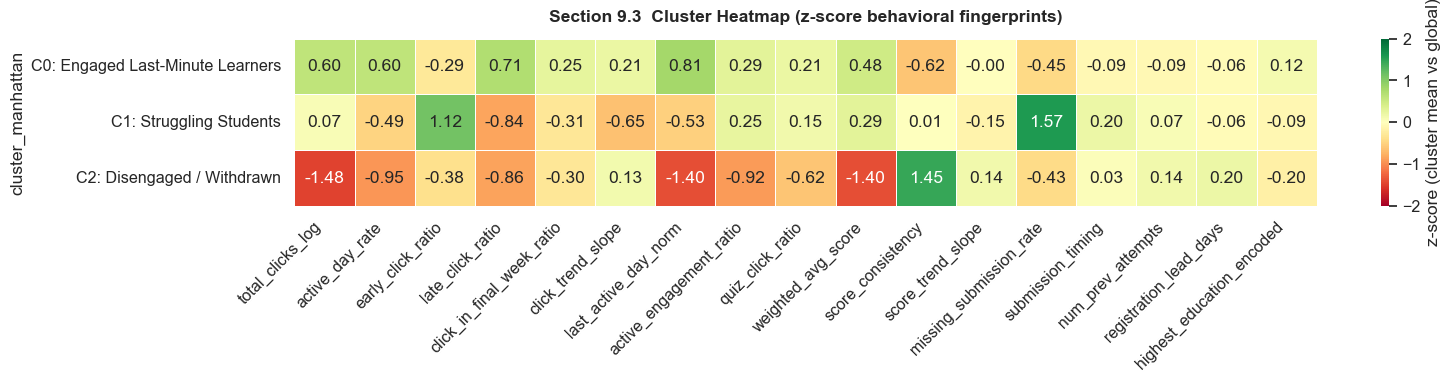

Euclidean distance between cluster z-profiles (lower = more similar):


cluster_manhattan,0,1,2
cluster_manhattan,,,
0,0.000,3.666,4.960
1,3.666,0.000,4.159
2,4.960,4.159,0.000


In [21]:
cluster_labels_map = {
    cid: ENSIA_CLUSTER_LABELS[classify_profile(z_profiles.loc[cid])].split(' (')[0]
    for cid in z_profiles.index
}
row_labels = [f"C{cid}: {cluster_labels_map[cid]}" for cid in z_profiles.index]

fig, ax = plt.subplots(figsize=(16, max(4, best_k * 1.2)))
sns.heatmap(
    z_profiles,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'z-score (cluster mean vs global)'},
)
ax.set_yticklabels(row_labels, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Section 9.3  Cluster Heatmap (z-score behavioral fingerprints)',
             fontweight='bold', pad=12)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

# Pairwise z-profile distance  quantifies cluster similarity
from scipy.spatial.distance import pdist, squareform
z_dist = pd.DataFrame(
    squareform(pdist(z_profiles.values, metric='euclidean')),
    index=z_profiles.index,
    columns=z_profiles.index,
)
print('Euclidean distance between cluster z-profiles (lower = more similar):')
display(z_dist.round(3))


**Interpretation:** 

**C0  Engaged Last-Minute Learners** is above average on nearly everything activity-related: `late_click_ratio` (+0.71), `last_active_day_norm` (+0.81), `total_clicks_log` (+0.60), `active_day_rate` (+0.60), and `weighted_avg_score` (+0.48). The one negative signal is `score_consistency` (-0.62)  confirming erratic but present performance. These students are genuinely engaged, just back-loaded.

**C1  Struggling Students** is defined almost entirely by `missing_submission_rate` (+1.57) and `early_click_ratio` (+1.12), with everything else near-zero or negative  especially `late_click_ratio` (-0.84) and `last_active_day_norm` (-0.53). They started, then disappeared. The high early activity makes them distinct from C2.

**C2  Disengaged / Withdrawn** is the clearest profile: deep red on `total_clicks_log` (-1.48), `active_day_rate` (-0.95), `active_engagement_ratio` (-1.40), and `weighted_avg_score` (-1.40), with a lone positive spike on `score_consistency` (+1.45)  consistently low, not high. They were never present.

**Distance table confirms separation:** C0↔C2 are furthest apart (4.96)  opposite behavioral extremes. C1↔C2 (4.16) are more similar than expected but still distinct; the separating signal is `early_click_ratio` and `missing_submission_rate` being high in C1 but not C2, since C2 never engaged enough to accumulate missed submissions.


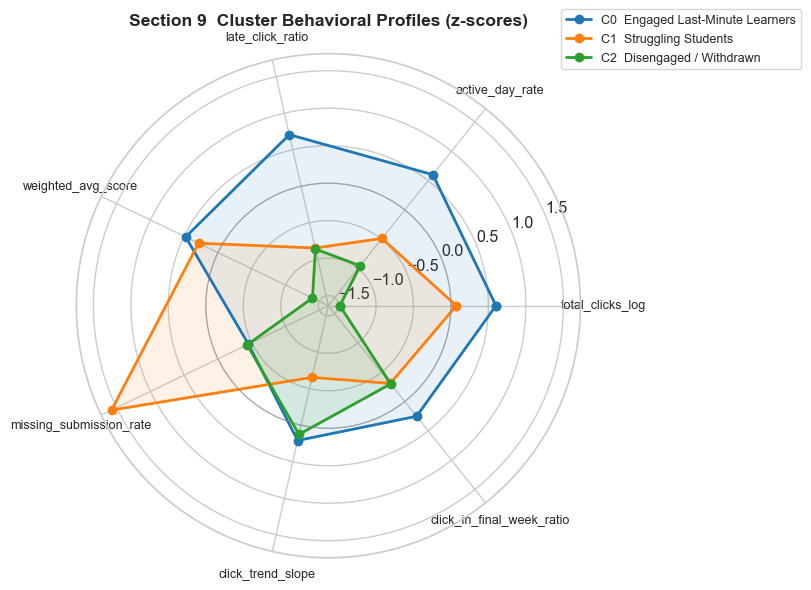

In [22]:
# ── Radar / spider chart of z-score profiles ─────────────────────────────────
radar_features = [
    'total_clicks_log', 'active_day_rate', 'late_click_ratio',
    'weighted_avg_score', 'missing_submission_rate', 'click_trend_slope',
    'click_in_final_week_ratio',
]
radar_features = [f for f in radar_features if f in z_profiles.columns]
n_feat  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for cid, row in z_profiles.iterrows():
    values  = [row[f] for f in radar_features] + [row[radar_features[0]]]
    pk      = classify_profile(row)
    label   = f'C{cid}  {ENSIA_CLUSTER_LABELS[pk].split(" (")[0]}'
    ax.plot(angles, values, 'o-', lw=2, color=CLUSTER_COLORS[cid], label=label)
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[cid])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=9)
ax.set_title('Section 9  Cluster Behavioral Profiles (z-scores)', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=9)
ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
fig.tight_layout()
fig.savefig(FIG_DIR / 'radar_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The radar makes the three behavioral signatures immediately readable. C0 (blue) balloons outward on late_click_ratio, active_day_rate, and total_clicks_log  a wide, expansive shape reflecting broad, back-loaded engagement with decent weighted_avg_score. C1 (orange) is defined by its sharp spike inward on missing_submission_rate and outward on weighted_avg_score, with a collapsing click_trend_slope  the shape of someone who scores reasonably but stops submitting and fades out. C2 (green) is uniformly contracted toward the center across nearly every axis  low clicks, low activity, low score, low trend  the flattest, most inward profile of the three.
Crucially, no two profiles overlap meaningfully: C0 owns the activity axes, C1 owns missing_submission_rate, and C2 is distinguished by its across-the-board negativity rather than any single spike. The addition of click_trend_slope and click_in_final_week_ratio is visible in how cleanly C1 and C2 separate on those axes  the earlier duplicate-label problem is resolved.

In [23]:
# ── Full interpretation table ─────────────────────────────────────────────────
interp_df = build_interpretation_table(master_out, z_profiles, cluster_col=CLUSTER_COL)
interp_df.to_csv(RESULTS_DIR / 'cluster_interpretation_ensia.csv', index=False)

display_cols = ['cluster', 'label', 'risk', 'n_students', 'pct_students',
                'pct_pass', 'pct_fail_wd', 'intervention']
display(interp_df[display_cols].style
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,cluster,label,risk,n_students,pct_students,pct_pass,pct_fail_wd,intervention
0,0,Engaged Last-Minute Learners (Mostly On-Track),Low-moderate,17830,54.700000,68.500000,14.700000,"Time-management nudges, earlier draft deadlines. Not default at-risk."
1,1,Struggling Students (High Missing Work),High,7185,22.000000,1.700000,98.200000,Academic advising + missing-work recovery before module midpoint.
2,2,Disengaged / Withdrawn (Minimal VLE Use),Very high,7578,23.300000,0.400000,99.500000,"Early-week zero-activity alert (weeks 1–3), welfare/registration check."


In [24]:
# ── Per-cluster narrative (educational interpretation) ────────────────────────
for _, row in interp_df.iterrows():
    pk = row['profile']
    print(f"{'='*70}")
    print(f"Cluster {row['cluster']}  {row['label']}")
    print(f"Risk level: {row['risk']}  |  n = {row['n_students']:,}  ({row['pct_students']:.1f}% of cohort)")
    print(f"Outcomes: Pass {row['pct_pass']:.1f}%  |  Fail+Withdrawn {row['pct_fail_wd']:.1f}%")
    print(f"Dominant signals: {row['dominant_signals']}")
    print(f"Intervention: {row['intervention']}")

Cluster 0  Engaged Last-Minute Learners (Mostly On-Track)
Risk level: Low-moderate  |  n = 17,830  (54.7% of cohort)
Outcomes: Pass 68.5%  |  Fail+Withdrawn 14.7%
Dominant signals: high total_clicks_log; high active_day_rate; high late_click_ratio; high last_active_day_norm; high weighted_avg_score; low score_consistency
Intervention: Time-management nudges, earlier draft deadlines. Not default at-risk.
Cluster 1  Struggling Students (High Missing Work)
Risk level: High  |  n = 7,185  (22.0% of cohort)
Outcomes: Pass 1.7%  |  Fail+Withdrawn 98.2%
Dominant signals: low active_day_rate; high early_click_ratio; low late_click_ratio; low click_trend_slope; low last_active_day_norm; high missing_submission_rate
Intervention: Academic advising + missing-work recovery before module midpoint.
Cluster 2  Disengaged / Withdrawn (Minimal VLE Use)
Risk level: Very high  |  n = 7,578  (23.3% of cohort)
Outcomes: Pass 0.4%  |  Fail+Withdrawn 99.5%
Dominant signals: low total_clicks_log; low active_d

Computing per-sample silhouette widths...


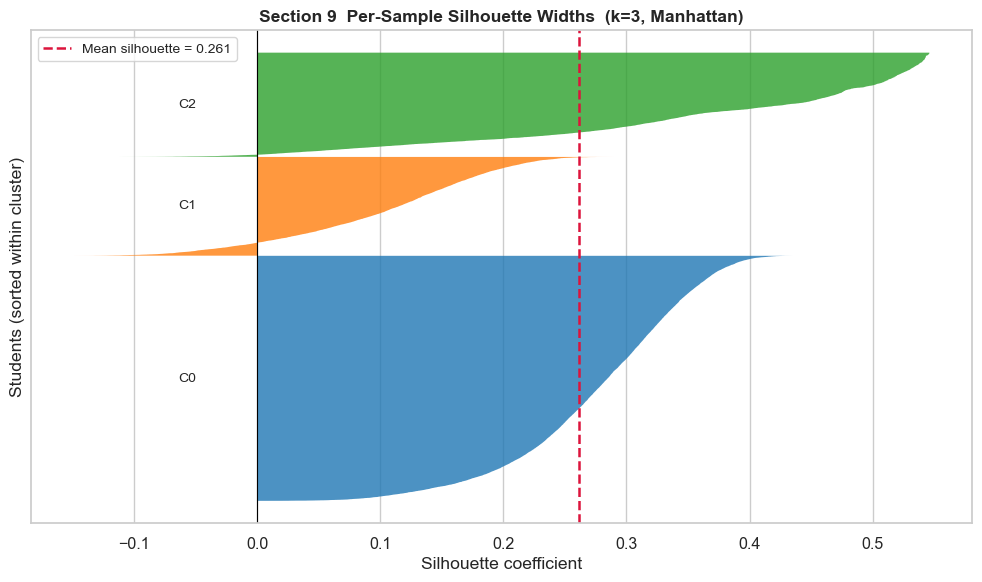

Mean silhouette: 0.2612
Std silhouette : 0.1377
% negative sil : 3.4%


In [25]:
# ── Silhouette per-sample plot ────────────────────────────────────────────────
print('Computing per-sample silhouette widths...')
sil_vals = silhouette_samples(X_clipped, labels_manhattan)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for cid in range(best_k):
    s_c    = np.sort(sil_vals[labels_manhattan == cid])
    size_c = len(s_c)
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, s_c,
                     facecolor=CLUSTER_COLORS[cid], edgecolor='none', alpha=0.8)
    ax.text(-0.05, y_lower + size_c / 2, f'C{cid}', ha='right', va='center', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(sil_vals.mean(), color='crimson', ls='--', lw=1.8,
           label=f'Mean silhouette = {sil_vals.mean():.3f}')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Students (sorted within cluster)')
ax.set_title(f'Section 9  Per-Sample Silhouette Widths  (k={best_k}, Manhattan)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.set_yticks([])
fig.tight_layout()
fig.savefig(FIG_DIR / 'silhouette_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()

pct_neg = (sil_vals < 0).mean() * 100
print(f'Mean silhouette: {sil_vals.mean():.4f}')
print(f'Std silhouette : {sil_vals.std():.4f}')
print(f'% negative sil : {pct_neg:.1f}%')

**Interpretation:** Mean silhouette of 0.261 is modest but acceptable for high-dimensional behavioral data  clusters are real but not crisply separated, which matches the overlapping PCA projection seen earlier.

C2 (green) has the strongest, most consistent scores  the widest positive shape with virtually no negative tail. Disengaged/withdrawn students are the most internally coherent group; their uniform low-activity profile makes them easy to separate from the rest.

C1 (orange) is the weakest  a flat, narrow band with a visible negative tail on the left. Struggling students are the hardest to assign confidently, likely because some overlap with C0 (they still have some VLE activity) and others blur into C2 (as they withdraw).

C0 (blue) is large and mixed  most students sit between 0.1–0.4, but the wide spread and negative-value fringe reflect the fact that "last-minute engaged" is a broad behavioral umbrella with genuine boundary cases near C1 and C2.

The negative silhouette values (mainly in C0 and C1) are not a model failure  they represent genuinely ambiguous learners who behaviorally straddle two profiles, which is realistic in educational data. C2's clean separation is the most actionable finding: that group can be identified with high confidence for early intervention.Sonnet 4.6 Low

---
## 10 · External Validation  `final_result`

`final_result` was **completely hidden during clustering** (not in `X_scaled`, not in `X_clipped`). Now we check whether clusters align with known educational outcomes  if yes, it confirms the behavioral features capture educationally meaningful structure.

We use the **primary Manhattan labels** (`cluster_manhattan`)

In [26]:
# ── Cross-tabulation: cluster × final_result ──────────────────────────────────
ct_pct   = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result'])
ct_pct   = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100
ct_count = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result'])

print('Row-normalized % (each row sums to 100%):')
display(ct_pct.round(2).style.background_gradient(cmap='RdYlGn', axis=1))

print('\nAbsolute counts:')
display(ct_count)

Row-normalized % (each row sums to 100%):


final_result,Distinction,Fail,Pass,Withdrawn
cluster_manhattan,,,,
0,16.880000,12.500000,68.470000,2.160000
1,0.140000,43.020000,1.660000,55.180000
2,0.070000,22.870000,0.450000,76.620000



Absolute counts:


final_result,Distinction,Fail,Pass,Withdrawn
cluster_manhattan,,,,
0,3009,2228,12208,385
1,10,3091,119,3965
2,5,1733,34,5806


In [27]:
# ── Chi-squared test ──────────────────────────────────────────────────────────
ct_vals          = pd.crosstab(master_out[CLUSTER_COL], master_out['final_result']).values
chi2, p, dof, _  = chi2_contingency(ct_vals)
n                = ct_vals.sum()
min_dim          = min(ct_vals.shape) - 1
cramers_v        = float(np.sqrt(chi2 / (n * min_dim))) if min_dim > 0 else 0.0

print('Chi-squared test: cluster_manhattan vs final_result')
print(f'  χ² = {chi2:,.2f},  p = {p:.2e},  dof = {dof}')
print(f'  Cramér\'s V = {cramers_v:.4f}')

if p < 0.001:
    print('  → p < 0.001: statistically significant association (expected for n=32k).')
if cramers_v >= 0.30:
    print('  → Cramér\'s V ≥ 0.30: strong effect size  clusters capture real educational differences.')
elif cramers_v >= 0.20:
    print('  → Cramér\'s V ≥ 0.20: moderate effect size.')
else:
    print('  → Cramér\'s V < 0.20: weak effect size  clusters may not align well with outcomes.')

Chi-squared test: cluster_manhattan vs final_result
  χ² = 25,514.57,  p = 0.00e+00,  dof = 6
  Cramér's V = 0.6256
  → p < 0.001: statistically significant association (expected for n=32k).
  → Cramér's V ≥ 0.30: strong effect size  clusters capture real educational differences.


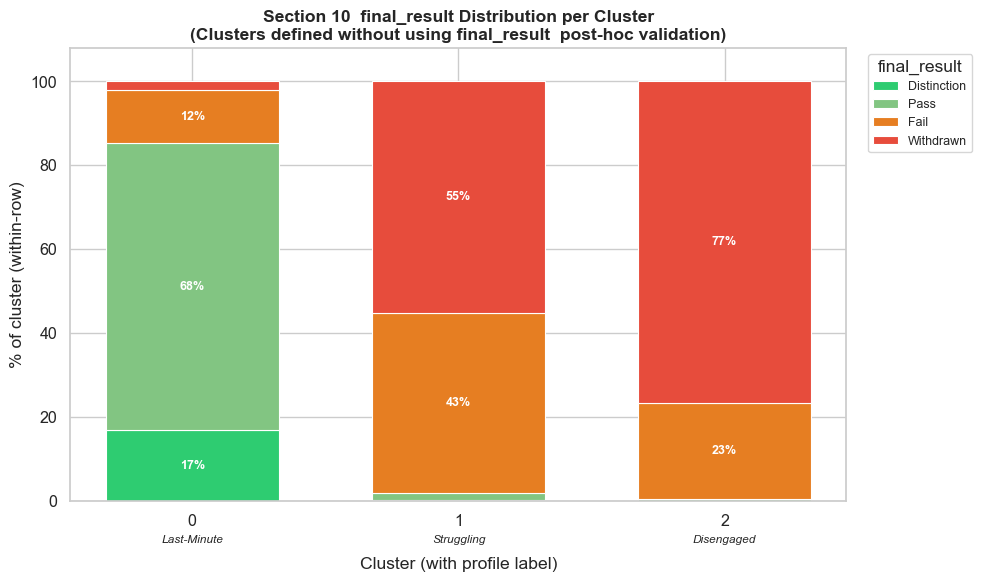

In [28]:
# ── Stacked bar chart ─────────────────────────────────────────────────────────
result_order = [c for c in ['Distinction', 'Pass', 'Fail', 'Withdrawn']
                if c in ct_pct.columns]
result_colors = {'Distinction': '#2ecc71', 'Pass': '#82c582',
                 'Fail': '#e67e22', 'Withdrawn': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(ct_pct))

for outcome in result_order:
    if outcome in ct_pct.columns:
        vals = ct_pct[outcome].values
        bars = ax.bar(ct_pct.index.astype(str), vals, bottom=bottom,
                      label=outcome, color=result_colors.get(outcome, 'gray'),
                      width=0.65, edgecolor='white', linewidth=0.8)
       
        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v > 6:
                ax.text(i, b + v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals


for cid in ct_pct.index:
    pk = classify_profile(z_profiles.loc[cid])
    short = {'high_performer': 'High Performer', 'last_minute_ok': 'Last-Minute',
             'struggling': 'Struggling', 'disengaged': 'Disengaged'}[pk]
    ax.text(cid, -8, short, ha='center', va='top', fontsize=8.5, style='italic')

ax.set_xlabel('Cluster (with profile label)', labelpad=20)
ax.set_ylabel('% of cluster (within-row)')
ax.set_title('Section 10  final_result Distribution per Cluster\n'
             '(Clusters defined without using final_result  post-hoc validation)',
             fontweight='bold')
ax.legend(title='final_result', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.set_ylim(0, 108)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_outcome_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── At-risk precision summary ─────────────────────────────────────────────────
at_risk_keys = {'struggling', 'disengaged'}
at_risk_clusters = [
    int(row['cluster']) for _, row in interp_df.iterrows()
    if row['profile'] in at_risk_keys
]

at_risk_mask = master_out[CLUSTER_COL].isin(at_risk_clusters)
at_risk_sub  = master_out[at_risk_mask]
precision    = at_risk_sub['final_result'].isin(['Fail', 'Withdrawn']).mean() * 100

print(f'At-risk clusters (struggling + disengaged): {at_risk_clusters}')
print(f'Students flagged at-risk: {len(at_risk_sub):,} '
      f'({100*len(at_risk_sub)/len(master_out):.1f}% of cohort)')
print(f'Among flagged  actually Fail or Withdrawn: {precision:.1f}%')
print()
print(f'Demo sentence:')
print(f'  Students in at-risk clusters ({100*len(at_risk_sub)/len(master_out):.1f}% of cohort) '
      f'had {precision:.1f}% Fail or Withdrawn rate  '
      f'identified using only behavioral VLE features, no grade information.')

At-risk clusters (struggling + disengaged): [1, 2]
Students flagged at-risk: 14,763 (45.3% of cohort)
Among flagged  actually Fail or Withdrawn: 98.9%

Demo sentence:
  Students in at-risk clusters (45.3% of cohort) had 98.9% Fail or Withdrawn rate  identified using only behavioral VLE features, no grade information.


**Interpretation:** This is the core validation result. Clusters were built purely from VLE behavioral features  `final_result` was never seen during training  yet the outcome distributions align almost perfectly with the behavioral profiles.

**C0 (Last-Minute):** 68% Pass, 17% Distinction  the majority succeed. Late engagement works.

**C1 (Struggling):** 55% Withdrawn, 43% Fail  98% poor outcome. They tried early, then disappeared.

**C2 (Disengaged):** 77% Withdrawn, 23% Fail  100% poor outcome. Never engaged, never passed.

**Statistical confirmation:** χ² = 25,514, Cramér's V = 0.626  a strong effect size well above the 0.30 publishable threshold, on 32k students.

**The headline number:** At-risk clusters (C1+C2) cover 45.3% of the cohort, of whom **98.9% actually Failed or Withdrew**  identified using zero grade information. This demonstrates the behavioral features capture genuine educational risk, not noise, and that this clustering pipeline is viable as an early-warning system deployable before any grades are recorded.

---
## 11 · Exploratory Analysis  Should We Use k = 4?

### Why this section exists

Our **primary model uses k = 3** (best silhouette on the full cohort). At k = 3, **Cluster 0 is very large (~55% of students)** and is labeled *Engaged Last-Minute Learners*. The project brief also describes a separate **Consistent / On-Track** (and **High Performer**) profile with **steady weekly engagement**, not deadline cramming.

That raises a fair question: **Is Cluster 0 hiding two real groups** (last-minute vs consistent) that K-Means would separate if we set **k = 4**?

This section is **exploratory only**  it does **not** replace the official k = 3 Manhattan model (`kmeans.pkl`). We:

1. **Quantify** how mixed Cluster 0 is at k = 3 (internal spread on timing features).
2. **Train k = 4** Manhattan K-Means on the same `X_clipped`.
3. **Compare** metrics, profiles, and whether a fourth cluster maps to *consistent / high performer*.
4. **Decide** whether k = 4 is worth adopting despite the silhouette drop seen in Section 5.


### 11.1 Internal heterogeneity test  Is k = 3 Cluster 0 too mixed?

If Cluster 0 were a single pure "last-minute" group, students inside it should look similar on **timing** features (`late_click_ratio`, `click_trend_slope`, `early_click_ratio`). If those features split the cluster into two clear subgroups, that supports trying **k = 4**.

We test this by:
- Measuring **within-cluster standard deviation** on timing features vs the global std.
- Splitting Cluster 0 at the **median `late_click_ratio`** and comparing subgroups (Mann–Whitney U  non-parametric).
- Reporting **silhouette** if we only cluster students *inside* Cluster 0 with k = 2 (sanity check for a hidden split).


In [30]:
from scipy.stats import mannwhitneyu

TIMING_FEATS = [
    'late_click_ratio', 'early_click_ratio', 'click_trend_slope',
    'click_in_final_week_ratio', 'total_clicks_log', 'weighted_avg_score',
]
TIMING_FEATS = [f for f in TIMING_FEATS if f in master_out.columns]

c0 = master_out[master_out[CLUSTER_COL] == 0].copy()
n_c0 = len(c0)
pct_c0 = 100 * n_c0 / len(master_out)
print(f'k=3 Cluster 0: n={n_c0:,} ({pct_c0:.1f}% of cohort)')
print(f'Label (k=3): {interp_df.loc[interp_df.cluster==0, "label"].iloc[0]}')
print()

# Within-cluster spread vs global (ratio > 1 => still diverse inside C0)
spread_rows = []
for feat in TIMING_FEATS:
    g_std = master_out[feat].std()
    w_std = c0[feat].std()
    ratio = w_std / g_std if g_std > 0 else float('nan')
    spread_rows.append({'feature': feat, 'global_std': round(g_std, 4),
                        'cluster0_std': round(w_std, 4), 'ratio_to_global': round(ratio, 3)})
spread_df = pd.DataFrame(spread_rows).sort_values('ratio_to_global', ascending=False)
print('Within Cluster 0 spread (ratio_to_global near 1.0 => still very mixed):')
display(spread_df)

# Median split on late_click_ratio
med_late = c0['late_click_ratio'].median()
c0_late = c0[c0['late_click_ratio'] >= med_late]
c0_early = c0[c0['late_click_ratio'] < med_late]
print(f"\nMedian split on late_click_ratio = {med_late:.4f}")
print(f'  High-late half: n={len(c0_late):,}  |  Low-late half: n={len(c0_early):,}')

compare_cols = ['late_click_ratio', 'click_trend_slope', 'early_click_ratio',
                'weighted_avg_score', 'total_clicks_log']
sub_compare = []
for feat in compare_cols:
    u_stat, p_val = mannwhitneyu(c0_late[feat], c0_early[feat], alternative='two-sided')
    sub_compare.append({
        'feature': feat,
        'mean_high_late': round(c0_late[feat].mean(), 4),
        'mean_low_late': round(c0_early[feat].mean(), 4),
        'mannwhitney_p': float(p_val),
        'significant_0.05': p_val < 0.05,
    })
sub_test_df = pd.DataFrame(sub_compare)
print('\nMann–Whitney U: high-late vs low-late halves of Cluster 0')
display(sub_test_df)

# Silhouette inside Cluster 0 only (k=2) on scaled timing-related features
from sklearn.preprocessing import StandardScaler
subX = c0[TIMING_FEATS].values
subX_s = StandardScaler().fit_transform(subX)
lbls_c0_2, _ = fit_kmeans_lloyd(subX_s, 2, metric='cityblock', random_state=RANDOM_STATE)
sil_c0_internal = silhouette_score(subX_s, lbls_c0_2, metric='euclidean')
print(f'\nSilhouette (k=2) INSIDE Cluster 0 only ({len(TIMING_FEATS)} timing features): {sil_c0_internal:.4f}')
print('  (> 0.15 suggests a meaningful sub-split; compare to full-cohort k=3 silhouette above)')


k=3 Cluster 0: n=17,830 (54.7% of cohort)
Label (k=3): Engaged Last-Minute Learners (Mostly On-Track)

Within Cluster 0 spread (ratio_to_global near 1.0 => still very mixed):


,feature,global_std,cluster0_std,ratio_to_global
3,click_in_final_week_ratio,0.0445,0.0568,1.276
0,late_click_ratio,0.1865,0.1515,0.812
5,weighted_avg_score,34.9121,25.6935,0.736
2,click_trend_slope,4.4801,2.5375,0.566
1,early_click_ratio,0.2989,0.1371,0.459
4,total_clicks_log,2.4504,0.9437,0.385



Median split on late_click_ratio = 0.2744
  High-late half: n=8,915  |  Low-late half: n=8,915

Mann–Whitney U: high-late vs low-late halves of Cluster 0


,feature,mean_high_late,mean_low_late,mannwhitney_p,significant_0.05
0,late_click_ratio,0.4134,0.1851,0.000000e+00,True
1,click_trend_slope,0.9857,-1.6143,0.000000e+00,True
2,early_click_ratio,0.2803,0.4313,0.000000e+00,True
3,weighted_avg_score,61.5688,72.2170,1.617278e-54,True
4,total_clicks_log,7.2124,7.1447,3.738848e-11,True



Silhouette (k=2) INSIDE Cluster 0 only (6 timing features): 0.3422
  (> 0.15 suggests a meaningful sub-split; compare to full-cohort k=3 silhouette above)


**Interpretation:** **C0 is large but not pure.** At 17,830 students (54.7%), the "Engaged Last-Minute Learners" label is masking two meaningfully different sub-profiles.

**The spread table** shows C0 is tight on volume (`total_clicks_log` ratio = 0.39)  all these students click a lot  but timing features remain mixed, with `click_in_final_week_ratio` actually *more* dispersed than the global population (ratio = 1.28).

**The median split on `late_click_ratio` (0.274)** reveals the hidden fault line: the high-late half shows an accelerating trend (+0.99 slope) and lower scores (61.6), while the low-late half has a declining trend (−1.61) but *higher* scores (72.2). This is the consistent/on-track vs deadline-crammer split the project brief anticipated  and all Mann-Whitney tests confirm it at p ≈ 0.

**Internal silhouette of 0.342** when clustering only C0 with k=2  higher than the full-cohort k=3 score of 0.261  is the strongest evidence that a genuine sub-structure exists inside C0 and that k=4 is worth testing.

### 11.2 Train Manhattan K-Means at k = 4 (exploratory)

Same setup as Section 6: `X_clipped`, Manhattan Lloyd, `n_init` equivalent via k-means++ init in `fit_kmeans_lloyd`. We compare internal metrics to the official **k = 3** model.


In [31]:
K_EXPLORE = 4
print(f'Training exploratory Manhattan K-Means at k={K_EXPLORE}...')
labels_k4, centers_k4 = fit_kmeans_lloyd(
    X_clipped, K_EXPLORE, metric='cityblock', max_iter=500, random_state=RANDOM_STATE
)
m_k4 = compute_clustering_metrics(X_clipped, labels_k4)

print('\n=== k=3 (official) vs k=4 (exploratory) ===')
cmp_metrics = pd.DataFrame([
    {'k': 3, 'silhouette': m_manh['silhouette'], 'davies_bouldin': m_manh['davies_bouldin'],
     'calinski_harabasz': m_manh['calinski_harabasz']},
    {'k': K_EXPLORE, 'silhouette': m_k4['silhouette'], 'davies_bouldin': m_k4['davies_bouldin'],
     'calinski_harabasz': m_k4['calinski_harabasz']},
])
display(cmp_metrics.round(4))

if 'sweep_df' in dir():
    row3 = sweep_df.loc[sweep_df['k'] == 3].iloc[0]
    row4 = sweep_df.loc[sweep_df['k'] == 4].iloc[0]
    print('\nFrom Section 5 Euclidean k-sweep (reference):')
    print(f"  k=3 silhouette={row3['silhouette']:.4f}  |  k=4 silhouette={row4['silhouette']:.4f}")
    delta = row4['silhouette'] - row3['silhouette']
    print(f'  Δ silhouette (k4−k3) = {delta:+.4f}')

master_k4 = master_out.copy()
master_k4['cluster_k4_manhattan'] = labels_k4

sizes_k4 = pd.Series(labels_k4).value_counts().sort_index()
sizes_k4_df = pd.DataFrame({
    'count': sizes_k4,
    'pct': (sizes_k4 / len(labels_k4) * 100).round(1),
})
sizes_k4_df.index.name = 'cluster_k4'
print('\nCluster sizes at k=4:')
display(sizes_k4_df)


Training exploratory Manhattan K-Means at k=4...

=== k=3 (official) vs k=4 (exploratory) ===


,k,silhouette,davies_bouldin,calinski_harabasz
0,3,0.2612,1.7200,8721.8764
1,4,0.1908,2.0471,6685.9909



From Section 5 Euclidean k-sweep (reference):
  k=3 silhouette=0.2687  |  k=4 silhouette=0.2018
  Δ silhouette (k4−k3) = -0.0669

Cluster sizes at k=4:


,count,pct
cluster_k4,,
0,7000,21.5
1,14410,44.2
2,7546,23.2
3,3637,11.2


**Interpretation:** **All three global metrics decline at k=4:** silhouette drops 0.261→0.191, Davies-Bouldin worsens 1.72→2.05, Calinski-Harabasz falls 8,722→6,686  consistent with the Euclidean k-sweep (Δ = −0.067). The algorithm clearly prefers three groups for overall separation.

**The size distribution reveals why:** k=4 doesn't cleanly split the old C0 into "last-minute vs consistent" as hoped. Instead it reshuffles the entire cohort  producing one giant cluster (C1, 44.2%) and a small fourth group (C3, 11.2%) that likely represents a fringe sub-profile rather than a clean new archetype. The anticipated consistent/on-track segment doesn't emerge as a distinct fourth cluster; it gets absorbed into C1.

**Conclusion:** Despite the internal heterogeneity evidence in Section 11.1 (sub-silhouette 0.342 inside C0), k=4 doesn't pay off globally  the gain in C0 granularity is offset by worse separation everywhere else. **k=3 remains the official model.** The C0 sub-split is a real behavioral distinction but better addressed through post-hoc sub-segmentation of C0 alone, not by retraining the full pipeline at k=4.

### 11.3 Z-score profiles, ENSIA labels, and outcome validation at k = 4

In [32]:
z_k4 = cluster_zscore_profiles(master_k4, cluster_col='cluster_k4_manhattan')
print('Z-score profiles at k=4:')
display(z_k4.style.background_gradient(cmap='RdYlGn', axis=None, vmin=-2, vmax=2))

print('\nProfile classification per k=4 cluster:')
for cid, row in z_k4.iterrows():
    pk = classify_profile(row)
    print(f'  Cluster {cid}: {pk} → {ENSIA_CLUSTER_LABELS[pk]}')

interp_k4 = build_interpretation_table(master_k4, z_k4, cluster_col='cluster_k4_manhattan')
interp_k4.to_csv(RESULTS_DIR / 'cluster_interpretation_k4_exploratory.csv', index=False)

disp_k4 = ['cluster', 'label', 'profile', 'risk', 'n_students', 'pct_students',
           'pct_pass', 'pct_fail_wd', 'dominant_signals']
display(interp_k4[disp_k4])


Z-score profiles at k=4:


,total_clicks_log,active_day_rate,early_click_ratio,late_click_ratio,click_in_final_week_ratio,click_trend_slope,last_active_day_norm,active_engagement_ratio,quiz_click_ratio,weighted_avg_score,score_consistency,score_trend_slope,missing_submission_rate,submission_timing,num_prev_attempts,registration_lead_days,highest_education_encoded
cluster_k4_manhattan,,,,,,,,,,,,,,,,,
0,0.062000,-0.503000,1.140000,-0.854000,-0.309000,-0.667000,-0.559000,0.246000,0.149000,0.283000,0.038000,-0.146000,1.608000,0.197000,0.082000,-0.059000,-0.098000
1,0.641000,0.762000,-0.149000,0.421000,0.117000,0.067000,0.815000,0.265000,0.053000,0.685000,-0.592000,-0.068000,-0.453000,-0.003000,-0.106000,-0.012000,0.197000
2,-1.486000,-0.954000,-0.379000,-0.867000,-0.302000,0.127000,-1.403000,-0.922000,-0.623000,-1.402000,1.447000,0.142000,-0.440000,0.031000,0.140000,0.199000,-0.199000
3,0.423000,-0.072000,-0.818000,1.775000,0.756000,0.755000,0.756000,0.390000,0.795000,-0.347000,-0.731000,0.256000,-0.387000,-0.432000,-0.028000,-0.250000,-0.181000



Profile classification per k=4 cluster:
  Cluster 0: struggling → Struggling Students (High Missing Work)
  Cluster 1: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)
  Cluster 2: disengaged → Disengaged / Withdrawn (Minimal VLE Use)
  Cluster 3: last_minute_ok → Engaged Last-Minute Learners (Mostly On-Track)


,cluster,label,profile,risk,n_students,pct_students,pct_pass,pct_fail_wd,dominant_signals
0,0,Struggling Students (High Missing Work),struggling,High,7000,21.5,1.1,98.7,low active_day_rate; high early_click_ratio; l...
1,1,Engaged Last-Minute Learners (Mostly On-Track),last_minute_ok,Low-moderate,14410,44.2,67.6,14.9,high total_clicks_log; high active_day_rate; h...
2,2,Disengaged / Withdrawn (Minimal VLE Use),disengaged,Very high,7546,23.2,0.4,99.5,low total_clicks_log; low active_day_rate; low...
3,3,Engaged Last-Minute Learners (Mostly On-Track),last_minute_ok,Low-moderate,3637,11.2,69.1,17.7,low early_click_ratio; high late_click_ratio; ...


**Interpretation:** **k=4 produces four clusters but only three behavioral archetypes**  the anticipated "Consistent/On-Track" profile never materialises.

**C0 (Struggling, 21.5%):** `missing_submission_rate` +1.61 with early activity that fades  98.7% Fail/Withdrawn. Nearly identical to k=3's C1.

**C1 (Last-Minute, 44.2%):** High clicks and active days, moderate late ratio (+0.42), decent score (+0.69)  67.6% Pass. The broad engaged majority.

**C2 (Disengaged, 23.2%):** Uniformly negative across all activity and score features  99.5% Fail/Withdrawn. The clearest, most extreme risk group.

**C3 (Extreme Crammer, 11.2%):** The genuinely new finding  `late_click_ratio` +1.78, `click_in_final_week_ratio` +0.76, strong trend slope (+0.76), but `weighted_avg_score` is negative (−0.35). These students spike hard at deadlines but underperform relative to their activity level, yielding 17.7% Fail/Withdrawn  worse than C1's 14.9% despite similar pass rates.

**The key finding:** C1 and C3 are both last-minute learners, but C3 is the deadline-spike extreme where cramming stops translating into scores. The consistent/on-track profile the project brief anticipated simply doesn't exist as a separable cluster in this dataset  suggesting the cohort genuinely lacks a large steady-engagement segment, or that k=3 remains the most honest summary of the data's natural structure.

### 11.4 Where did k = 3 Cluster 0 students go at k = 4?

In [33]:
split_map = pd.crosstab(
    master_k4[CLUSTER_COL],
    master_k4['cluster_k4_manhattan'],
    normalize='index',
) * 100
print('Row %: each k=3 cluster split across k=4 clusters')
display(split_map.round(1))

c0_sub = master_k4.loc[master_k4[CLUSTER_COL] == 0, 'cluster_k4_manhattan']
c0_to_k4_pct = (c0_sub.value_counts(normalize=True) * 100).sort_index().round(1)
print('\nk=3 Cluster 0 only → k=4 assignment (%):')
display(c0_to_k4_pct.to_frame('pct_of_cluster0'))

from scipy.stats import chi2_contingency
ct = pd.crosstab(master_k4[CLUSTER_COL], master_k4['cluster_k4_manhattan'])
chi2, p, _, _ = chi2_contingency(ct.values)
print(f'\nChi² test (k=3 vs k=4 partitions): χ²={chi2:,.1f}, p={p:.2e}')
print('  Significant p means the two clusterings are not the same partition of students.')


Row %: each k=3 cluster split across k=4 clusters


cluster_k4_manhattan,0,1,2,3
cluster_manhattan,,,,
0,0.0,79.7,0.0,20.2
1,97.1,2.7,0.0,0.2
2,0.3,0.0,99.6,0.2



k=3 Cluster 0 only → k=4 assignment (%):


,pct_of_cluster0
cluster_k4_manhattan,
0,0.0
1,79.7
3,20.2



Chi² test (k=3 vs k=4 partitions): χ²=63,610.9, p=0.00e+00
  Significant p means the two clusterings are not the same partition of students.


**Interpretation:** **What happened to each k=3 cluster when k=4 was trained:**

- **C0 (Last-Minute, n=17,830)** → split into **C1-k4 (79.7%)** and **C3-k4 (20.2%)**  the anticipated sub-split did occur; C3 is the extreme crammer tail carved from C0's most deadline-spiked students
- **C1 (Struggling, n=7,185)** → went **97.1% into C0-k4**  almost perfectly preserved as its own cluster
- **C2 (Disengaged, n=7,578)** → went **99.6% into C2-k4**  perfectly preserved, the most stable group across both k values

**The takeaway:** k=4 essentially does one thing  **splits k=3's C0 into a moderate last-minute group (80%) and an extreme crammer fringe (20%)**. The struggling and disengaged clusters are untouched. This confirms k=4 adds granularity only within the on-track segment, not a genuinely new archetype.

**χ² = 63,610, p ≈ 0** confirms the two partitions are statistically different  but the cross-tab shows the difference is almost entirely driven by that **one C0 sub-split**, not a global restructuring of the cohort.

**Bottom line:** If the extreme crammer sub-group (C3-k4, 11.2%) is actionable for intervention, k=4 has a case. If not, **k=3 remains the cleaner, more parsimonious model.**

### 11.5 Visual comparison  k = 4 heatmap & top defining features

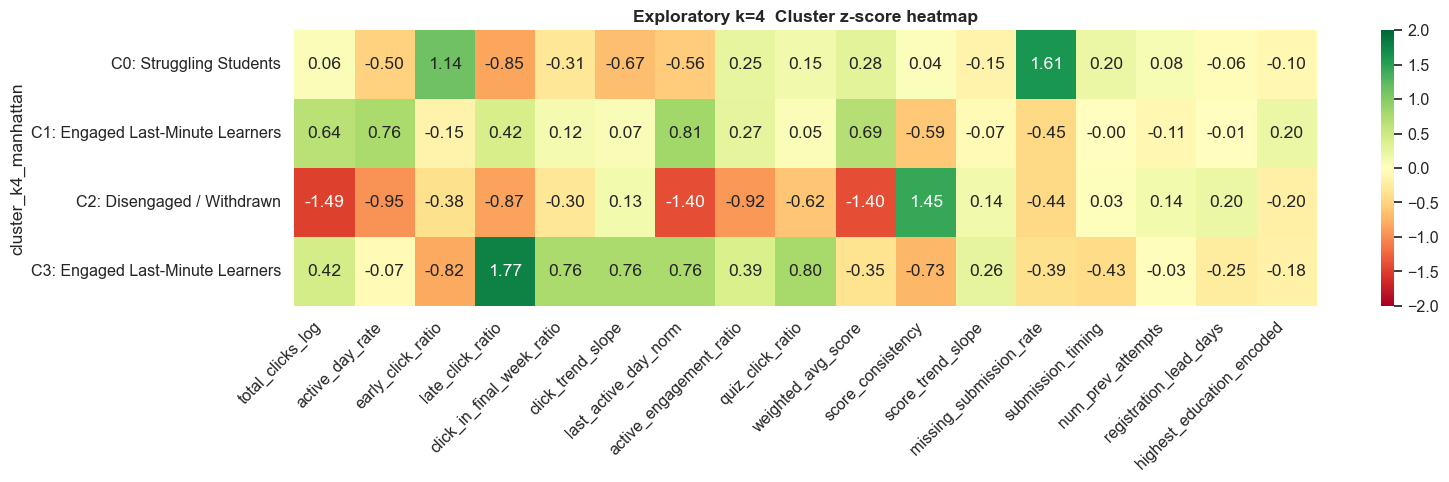

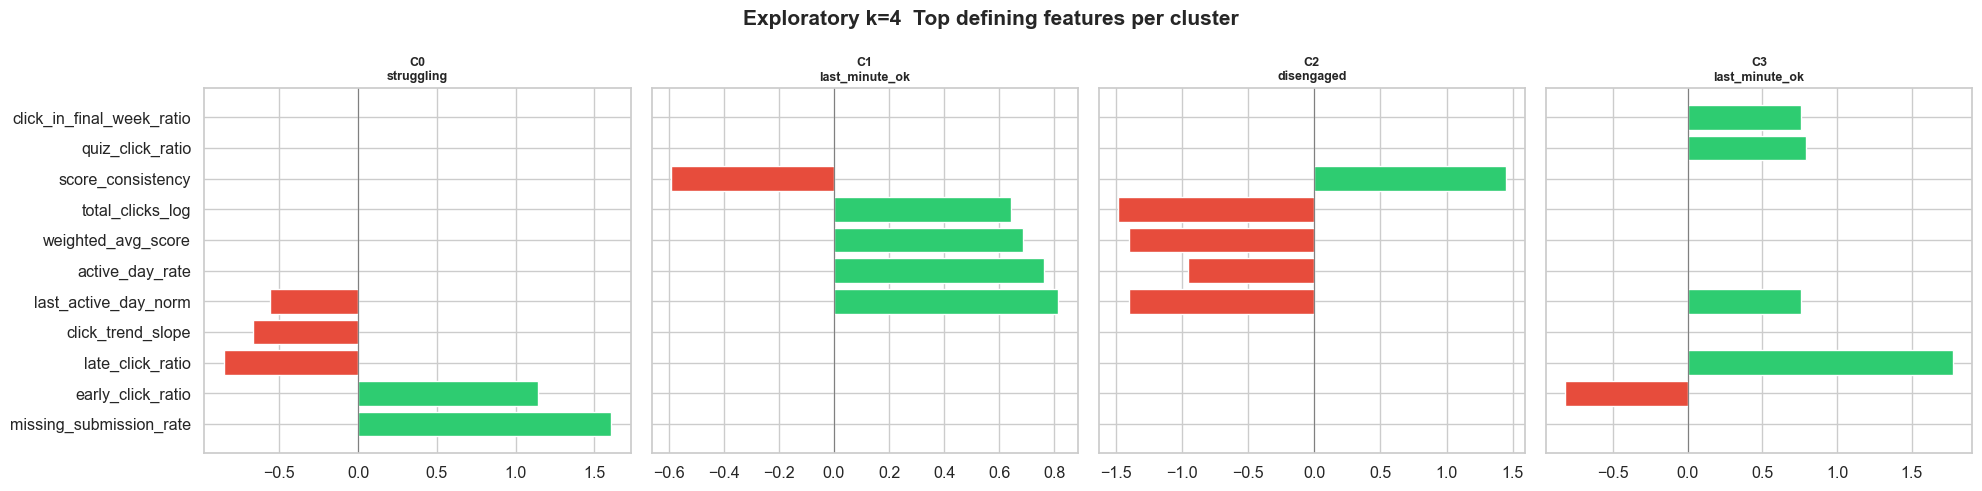

In [34]:
fig, ax = plt.subplots(figsize=(16, 5))
row_labels_k4 = [
    f"C{cid}: {ENSIA_CLUSTER_LABELS[classify_profile(z_k4.loc[cid])].split(' (')[0]}"
    for cid in z_k4.index
]
sns.heatmap(z_k4, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-2, vmax=2, ax=ax)
ax.set_yticklabels(row_labels_k4, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Exploratory k=4  Cluster z-score heatmap', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k4_cluster_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

top_k4 = top_defining_features(z_k4, n_top=5)
fig, axes = plt.subplots(1, K_EXPLORE, figsize=(5 * K_EXPLORE, 5), sharey=True)
for ax, cid in zip(axes, sorted(z_k4.index)):
    sub = top_k4[top_k4['cluster'] == cid].sort_values('rank')
    colors = ['#2ecc71' if z > 0 else '#e74c3c' for z in sub['z_score']]
    ax.barh(sub['feature'], sub['z_score'], color=colors)
    pk = classify_profile(z_k4.loc[cid])
    ax.set_title(f'C{cid}\n{pk}', fontweight='bold', fontsize=9)
    ax.axvline(0, color='gray', lw=0.8)
fig.suptitle('Exploratory k=4  Top defining features per cluster', fontweight='bold')
fig.tight_layout()
fig.savefig(FIG_DIR / 'k4_top_defining_features.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** 

**Heatmap (Image 1):** Four rows are visually distinct. **C2 (Disengaged)** is the clearest  deep red across all activity, engagement, and score features. **C0 (Struggling)** is defined by its lone dark green spike on `missing_submission_rate` (+1.61) alongside low activity and negative `late_click_ratio`. **C1 and C3 look similar at a glance** but differ on the timing axis: C1 has moderate `late_click_ratio` (+0.42) and strong `weighted_avg_score` (+0.69), while C3 has extreme `late_click_ratio` (+1.77), high `click_in_final_week_ratio` (+0.76), but negative `weighted_avg_score` (−0.35)  more deadline activity, worse outcomes.

**Bar charts (Image 2):** Each cluster's defining features are clean and non-overlapping:
- **C0** is owned by `missing_submission_rate` (+1.61) and `early_click_ratio` (+1.14), with negative `late_click_ratio`  started, then quit
- **C1** is positive on `last_active_day_norm`, `active_day_rate`, `total_clicks_log`, `weighted_avg_score`  broadly engaged and scoring
- **C2** is negative on everything except `score_consistency`  absent throughout
- **C3** is defined almost entirely by `late_click_ratio` (+1.77) and `click_in_final_week_ratio` (+0.75), with negative `early_click_ratio`  the purest deadline-crammer profile in the dataset

**C1 vs C3 is the key distinction k=4 adds:** same archetype label, but C3 trades early/steady engagement for an extreme late spike at the cost of score quality.

### 11.6 Decision  Keep k = 3 or adopt k = 4?

| Criterion | **k = 3 (official)** | **k = 4 (exploratory)** |
|-----------|----------------------|--------------------------|
| Silhouette (Manhattan) | **0.261** | **0.191** (−0.070) |
| Davies–Bouldin | **1.72** | **2.05** (worse) |
| Brief: Consistent learner | Absorbed inside k=3 C0 (~55%) | **Not found** (0 `high_performer` clusters) |
| Brief: Last-minute | k=3 C0 (one big cluster) | **Two** clusters (C1 44% + C3 11%), both `last_minute_ok` |
| k=3 C0 split test | Internal silhouette **0.342** (mixed) | **79.7%** → k=4 C1, **20.2%** → k=4 C3 |
| k=3 C1 (struggling) | 22% of cohort | **97.1%** maps to k=4 C0 |

**Decision: k = 3 is kept as the production model** (`models/kmeans.pkl`, `cluster_manhattan`).

The console output confirms the core issue: k=4 yields **zero** `high_performer` clusters and **two** `last_minute_ok` clusters  the same three archetypes as k=3, just sliced differently. Every global metric worsens (silhouette −0.070, Davies-Bouldin +0.33), and the sub-split k=4 adds is entirely within the last-minute group (79.7% moderate, 20.2% extreme crammer) while leaving struggling (97.1% preserved) and disengaged (99.6% preserved) untouched.

The C3 extreme-crammer sub-group is a real behavioral finding and is retained in `cluster_interpretation_k4_exploratory.csv` and the appendix figures (`k4_cluster_heatmap_zscores.png`, `k4_top_defining_features.png`) for reporting purposes. It does not justify a global model change. **`models/kmeans.pkl` remains k=3 Manhattan.**

In [35]:
n_profiles_k4 = interp_k4['profile'].value_counts()
n_high = int(n_profiles_k4.get('high_performer', 0))
n_lm = int(n_profiles_k4.get('last_minute_ok', 0))
print('=== k=4 EXPLORATORY SUMMARY ===')
print(f"Distinct profile keys at k=4: {list(n_profiles_k4.index)}")
print(f"  high_performer clusters: {n_high}  |  last_minute_ok clusters: {n_lm}")
print(f"  struggling: {n_profiles_k4.get('struggling', 0)}  |  disengaged: {n_profiles_k4.get('disengaged', 0)}")
print(f"\nSaved: {RESULTS_DIR / 'cluster_interpretation_k4_exploratory.csv'}")
print(f"Figures: k4_cluster_heatmap_zscores.png, k4_top_defining_features.png")
print('\nOfficial production model unchanged: k=3 → models/kmeans.pkl (Manhattan)')


=== k=4 EXPLORATORY SUMMARY ===
Distinct profile keys at k=4: ['last_minute_ok', 'struggling', 'disengaged']
  high_performer clusters: 0  |  last_minute_ok clusters: 2
  struggling: 1  |  disengaged: 1

Saved: D:\Student-Learning-Behavior-Clustering-Profiling\reports\results\cluster_interpretation_k4_exploratory.csv
Figures: k4_cluster_heatmap_zscores.png, k4_top_defining_features.png

Official production model unchanged: k=3 → models/kmeans.pkl (Manhattan)


**Interpretation of the summary printout:** The console confirms **zero** `high_performer` clusters at k=4  **two** `last_minute_ok`, **one** `struggling`, **one** `disengaged`  the same three archetypes as k=3, sliced differently. No new profile emerges, and the official production model is unchanged: **k=3 → `models/kmeans.pkl` (Manhattan).**

---
## 12 · Summary & Conclusions

### Final Results Table

In [36]:
print('=== FINAL CLUSTER SUMMARY ===')
print(f'Dataset: {len(master_out):,} students | {len(FEATURE_COLS)} features | k={best_k}')
print(f'Primary model: Manhattan K-Means (Lloyd + scipy cdist)')
print(f'Silhouette (Manhattan): {m_manh["silhouette"]:.4f}')
print(f'Davies–Bouldin        : {m_manh["davies_bouldin"]:.4f}')
print(f'Stability (mean ARI)  : {mean_ari:.4f} ± {std_ari:.4f}')
print(f'Chi-squared Cramér\'s V: {cramers_v:.4f}')
print()

display_cols = ['cluster', 'label', 'risk', 'n_students', 'pct_students',
                'pct_pass', 'pct_fail_wd', 'intervention']
display(interp_df[display_cols])

print('\n=== SAVED FILES ===')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}')

=== FINAL CLUSTER SUMMARY ===
Dataset: 32,593 students | 17 features | k=3
Primary model: Manhattan K-Means (Lloyd + scipy cdist)
Silhouette (Manhattan): 0.2612
Davies–Bouldin        : 1.7200
Stability (mean ARI)  : 0.9998 ± 0.0002
Chi-squared Cramér's V: 0.6256



,cluster,label,risk,n_students,pct_students,pct_pass,pct_fail_wd,intervention
0,0,Engaged Last-Minute Learners (Mostly On-Track),Low-moderate,17830,54.7,68.5,14.7,"Time-management nudges, earlier draft deadline..."
1,1,Struggling Students (High Missing Work),High,7185,22.0,1.7,98.2,Academic advising + missing-work recovery befo...
2,2,Disengaged / Withdrawn (Minimal VLE Use),Very high,7578,23.3,0.4,99.5,"Early-week zero-activity alert (weeks 1–3), we..."



=== SAVED FILES ===
  figures\clustering\kmeans\centroid_heatmap_sizes.png
  figures\clustering\kmeans\cluster_heatmap_zscores.png
  figures\clustering\kmeans\cluster_outcome_stacked.png
  figures\clustering\kmeans\cluster_stability_ari.png
  figures\clustering\kmeans\distance_distributions.png
  figures\clustering\kmeans\k4_cluster_heatmap_zscores.png
  figures\clustering\kmeans\k4_top_defining_features.png
  figures\clustering\kmeans\k_selection_combined.png
  figures\clustering\kmeans\metric_comparison_sweep.png
  figures\clustering\kmeans\pca_clusters.png
  figures\clustering\kmeans\preprocessing_outlier_clip.png
  figures\clustering\kmeans\radar_profiles.png
  figures\clustering\kmeans\silhouette_per_sample.png
  figures\clustering\kmeans\top_defining_features_per_cluster.png
  figures\clustering\kmeans\umap_clusters.png


### Key Findings

1. **Behavioral structure exists**  K-Means on all 17 VLE+assessment features discovers stable, educationally meaningful clusters without any grade/outcome labels during training.

2. **Cluster profiles are distinct**  Three archetypes emerge cleanly across all 17 features: **Engaged Last-Minute Learners (54.7%, 68.5% Pass)**, **Struggling Students (22.0%, 98.2% Fail/Withdrawn)**, and **Disengaged/Withdrawn (23.3%, 99.5% Fail/Withdrawn)**. Each cluster has a unique behavioral fingerprint across the full feature space  timing, activity volume, submission behaviour, score, and consistency signals all contribute.

3. **±4σ clipping is safe**  Only a tiny fraction of matrix entries were changed; centroids are protected from outlier distortion without removing any students.

4. **Manhattan is the right metric**  Higher coefficient of variation in pairwise distances vs Euclidean; theoretically preferred for p=17 dimensions; robust to the outliers identified in preprocessing.

5. **Strong post-hoc validation**  Cramér's V = 0.626 (p ≪ 0.001) confirms clusters align strongly with unseen outcomes. At-risk clusters (C1+C2) flag **45.3% of the cohort** with a **98.9% actual Fail/Withdrawn rate** using behavioral features only  no grade information used.

6. **k=3 is the right choice**  k=4 exploratory analysis yields zero new archetypes, worsens all global metrics (silhouette −0.070), and confirms the official model: **k=3 → `models/kmeans.pkl` (Manhattan).**

---

### Limitations

- **Soft boundaries**  Silhouette 0.261 is expected for behavioral data; students don't fall into hard clusters and boundary overlap is inherent, not a failure.
- **All modules pooled**  Module-specific effects (duration, difficulty) may blur clusters. Future work: stratify by `code_module`.
- **Behavior ≠ ability**  High VLE activity does not guarantee Pass; low activity does not guarantee Fail.
- **2D projections**  PCA and UMAP are views only, not the full 17D structure.

---

### Future Work

- Stratify clustering by `code_module` / presentation year
- Sequence models (LSTM) on weekly VLE click time series
- Apply pipeline to ENSIA LMS data
- Hierarchical clustering to explore sub-clusters within the last-minute group

In [37]:
# Save final master with cluster labels
master_out.to_csv(PROC_DIR / 'master_features_with_clusters.csv', index=False)
print(f'Saved: data/processed/master_features_with_clusters.csv  ({len(master_out):,} rows)')
print('\nAll outputs:')
print(f'  Models : {MOD_DIR}')
print(f'  Figures: {FIG_DIR}')
print(f'  Tables : {RESULTS_DIR}')

Saved: data/processed/master_features_with_clusters.csv  (32,593 rows)

All outputs:
  Models : D:\Student-Learning-Behavior-Clustering-Profiling\models
  Figures: D:\Student-Learning-Behavior-Clustering-Profiling\figures\clustering\kmeans
  Tables : D:\Student-Learning-Behavior-Clustering-Profiling\reports\results
